# TOMOseq data analysis pipeline

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
from venn import venn
import scanpy as sc
import anndata as ad
import seaborn as sns
import math
from scipy.stats import zscore, variation, ttest_ind
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import dendrogram, linkage
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import normalize, scale, MinMaxScaler

Describe funciton to process de data

In [2]:
def accessData(list_files, list_labels):
    """opens the read/transcript/gene counts of each file"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(file, sep='\t', compression='gzip', index_col=0)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1
    
    return dic_dataframes


def saveCSV(dic_data, label):
    """Save dataframes inside dictionary to csv files"""
    for key in dic_data:
        dic_data[key].to_csv(key+'_'+label+'.tsv.gz', sep='\t', compression='gzip')
    
    return print('Files saved')



def normalizeTO(dic_data, factor):
    """Normalize to median/mean/factor
    1. divide by the total reads in each column (normalization)
    2. multiply by the factor of total raeds across sections (scaling)"""
    #make a counter for the smaple number to select the median position
    count = 0
    #make a dictionary to store the normalized datasets
    dic_normal = {}
    #Get each dataframe
    for key in dic_data:
        #get the total transcript counts per section
        data_frame_total = dic_data[key].sum(axis='index')
        #divide each section by the total of the section
        data_frame_normal_s1 = dic_data[key].divide(data_frame_total, axis='columns')
        #multiply by the meadian value 
        data_frame_normal = data_frame_normal_s1.multiply(factor)
        count = count + 1
        #save the dataframe to the dictionary
        dic_normal[key] = data_frame_normal
    
    return dic_normal


def zscores(dic_data):
    """Calculates de z scores for each gene individually"""
    #Create a dictinary to store the dataframes of z scores
    dic_zscores = {}
    for key in dic_data:
        #create a dataframe to store the zscores
        df_zscore = pd.DataFrame(columns = dic_data[key].columns, index = dic_data[key].index)
        #calculate z scores for each gene
        #for that we need to get the info from every row independently and then get the z score
        for index in dic_data[key].index.values:
            #transform the series into list, then to np.array and apply z score funtion from scipy.stats
            #and save it to the Zscore df
            data_gene = np.array(list(dic_data[key].loc[index]))
            df_zscore.loc[index] = zscore(data_gene.astype(float))
        #save the df_zscores to the dictionary
        dic_zscores[key] = df_zscore.astype(float)
    
    return dic_zscores


def scaledZscores(dic_data):
    """Calculates de scaled z scores for each gene individually.
    Normalize the Z score to scaled Z score (-1 to 1)"""
    #Create a dictinary to store the dataframes of z scores
    dic_scaled_zscores = {}
    for key in dic_data:
        #create a dataframe to store the zscores
        df_scaled_zscore = pd.DataFrame(columns = dic_data[key].columns, index = dic_data[key].index)
        #calculate z scores for each gene
        #for that we need to get the info from every row independently and then get the z score
        for index in dic_data[key].index.values:
            ## 1.convert the column value of the dataframe to floats
            float_array = dic_data[key].loc[index].values.astype(float)
            # Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.
            float_array = float_array.reshape(-1, 1)
            # 2. create a min max processing object
            min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
            scaled_array = min_max_scaler.fit_transform(float_array)
            # 3. convert the scaled array to dataframe. First reshape the array to the original shape
            scaled_array = scaled_array.reshape(len(dic_data[key].columns.values),)
            df_scaled_zscore.loc[index] = scaled_array
        #save the df_zscores to the dictionary 
        #Use astype(float) to ensure the values are numbers for correct plotting
        dic_scaled_zscores[key] = df_scaled_zscore.astype(float)
    
    return dic_scaled_zscores



## Anna's formulas for hierarchical clustering
def hierarchicalClustering(df, cth = 100, plot = False, method = 'ward', metric = 'euclidean', nolabels = 'True', leaf_colors = []):
    """performs hierarchical clustering using linkage and dendogram functions from scipy.cluster.hierarchy package"""
    if len(leaf_colors) > 0:
        hierarchy.set_link_color_palette(leaf_colors)
    df = df.replace(np.nan,0)
    Z = linkage(df, method=method, metric = metric)
    dg = dendrogram(Z, no_labels=nolabels, color_threshold=cth, no_plot = np.invert(plot))
    plt.show()
    return Z, dg


def getClusterByColor(dg, labels):
    """given a dendogram and labels, it groups labels by colors in the dendogram (i.e. clusters)"""
    kk = []
    ii = 0
    cluster = 0
    color = dg['color_list'][0]
    clusters = {cluster: []}
    for i in range(len(dg['icoord'])):
        v = dg['icoord'][i]
        for j in [0,2]:
            vj = int(round((v[j]-5.)/10))
            if (v[j]-5.)/10 == vj and vj not in kk:
                kk.append(vj)
                if dg['color_list'][i] == color:
                    clusters[cluster].append(labels[dg['leaves'][vj]])
                else:
                    color = dg['color_list'][i]
                    cluster += 1
                    clusters[cluster] = [labels[dg['leaves'][vj]]]
    return clusters


def plotHeatmap(dic_data, dg, clusters, figsize, title, type_data, reorganize = False, new_index_order = []):
    """Use the combined clustering to plot the indivudal heatmaps for each sample"""
    #access each dictionary and count the number of samples
    keys = []
    for key in dic_data:
        keys.append(key)      
    #check the number of samples to provide the width ratios
    ratios = [0.5]
    for element in range(len(keys)):
        if element < len(keys)-1:
            ratios.append(3)
        if element == len(keys)-1:
            ratios.append(4)
    # plot multiple plots with plt.sublots. axs is a list of all the subplots. Plot as many plots as samples plus 
    # one for the cluster label
    fig, axs = plt.subplots(nrows = 1, ncols = len(keys)+1, sharey='row', gridspec_kw={'width_ratios': ratios}, figsize = figsize);
    #make a count to access the correct plot
    count = 0
    for key in dic_data:
        if reorganize == False:
            #use dg['leaves'] indexes to organize the data to plot
            data_plot = dic_data[key].loc[dic_data[key].index[dg['leaves']]]
        if reorganize == True:
            data_plot = dic_data[key].reindex(index = new_index_order)
        # to plot I use ax.imshow
        im = axs[count+1].imshow(data_plot, aspect='auto', interpolation='none', cmap='viridis')
        # Hide grid lines
        axs[count+1].grid(False)
        # add labels
        axs[count+1].set_title(key)
        #remove ticks on the y axis
        axs[count+1].tick_params(top=False, bottom=True, left=False, right=False)
        #add 1 to the count to go to next sample
        count = count + 1
        
    
    #create the colour bar and label it, we use the last image (im)
    #cax = divider.append_axes('left', size='5%', pad=0.05)
    cb = fig.colorbar(im, orientation='vertical', shrink = 0.3)
    cb.set_label(type_data)

    # Make a big plot in order to craete shared axis labels
    # add a big axes, hide frame
    fig.add_subplot(111, frameon=False)
    # hide tick and tick label of the big axes
    plt.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    plt.grid(False)
    plt.xlabel("Sections Proximal-Distal (knee to ankle)")

    #Introduce the cluster bar
    #make the variable bottom to 0, which indicates were the cluster starts
    bottom = 0
    for cluster in clusters:
        if int(cluster) < len(clusters)-1: 
            #get the height of the cluster
            height = len(clusters[cluster])
            axs[0].bar(-0.5, height = height, bottom=bottom-0.5, width=0.2, align='center')
            #add cluster labels
            axs[0].text(-0.5, bottom-0.5+height/2, str(int(cluster)+1), ha='center', va='center')
            #add the length of the current cluster to the bottom variable for the next cluster start
            bottom = bottom + len(clusters[cluster])

        #I add -1 to the last bottom, otherwise the plot gets out of the grid
        if int(cluster) == len(clusters)-1:
            height = len(clusters[cluster])
            axs[0].bar(-0.5, height = height, bottom=bottom-0.5, width=0.2, align='center')
            #add cluster label
            axs[0].text(-0.5, bottom-0.5+height/2, str(int(cluster)+1), ha='center', va='center')

    #axs[0].set_ylim(0,bottom)  

    #remove ticks and plot frame from the cluster bar
    axs[0].tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    axs[0].axis('off')
    #add the figure title
    fig.suptitle(title, fontsize=13)
    
    
    
def ClusterGeneNames(data, clusters, dg, file_name):
    """Creates a txt file that contains the gene ids of each cluster to use for GO search"""
    #create the file
    #We declared the variable f to open a file . Open takes 2 arguments, the file that we want 
    #to open and a string that represents the kinds of permission or operation we want to do on the file
    #Here, we used "w" letter in our argument, which indicates write and will create a file if it does 
    #not exist in library
    #Plus sign indicates both read and write.
    f = open(file_name,"w+")
    #change the index order of the data in the heatmap
    data = data.index[dg['leaves']]
    #access the gene info of each cluster
    start = 0
    end = 0
    for key in clusters:
        #writte the cluster name
        #The output we want to iterate in the file is "Cluster ", which we declare with write function and 
        #then percent d (displays integer)
        #So basically we are putting in the line number that we are writing (key + 1), then putting it in a carriage 
        #return and a new line character
        f.write('\nCluster %d\r\n' % (int(key)+1))
        #go through each index to substract the gene id and write it on the file
        end = end + len(clusters[key])
        for element in data[start:end]:
            #split the index and save the gene id and new line
            info = element.split('_')
            f.write(str(info[1]) + '\n')
        start = start + len(clusters[key])
    #close the file when done
    f.close()
    
    return print(file_name)


def plotHeatmapAnn(dic_data, dg, clusters, figsize, title, type_data, g_annotate, reorganize = False, new_index_order = []):
    """Use the combined clustering to plot the indivudal heatmaps for each sample"""
    #access each dictionary and count the number of samples
    keys = []
    for key in dic_data:
        keys.append(key)      
    #check the number of samples to provide the width ratios
    ratios = [0.5]
    for element in range(len(keys)):
        if element < len(keys)-1:
            ratios.append(3)
        if element == len(keys)-1:
            ratios.append(4)
    # plot multiple plots with plt.sublots. axs is a list of all the subplots. Plot as many plots as samples plus 
    # one for the cluster label
    fig, axs = plt.subplots(nrows = 1, ncols = len(keys)+1, sharey='row', gridspec_kw={'width_ratios': ratios}, figsize = figsize);
    #make a count to access the correct plot
    count = 0
    for key in dic_data:
        if reorganize == False:
            #use dg['leaves'] indexes to organize the data to plot
            data_plot = dic_data[key].loc[dic_data[key].index[dg['leaves']]]
        if reorganize == True:
            data_plot = dic_data[key].reindex(index = new_index_order)
        # to plot I use ax.imshow
        im = axs[count+1].imshow(data_plot, aspect='auto', interpolation='none', cmap='viridis')
        # Hide grid lines
        axs[count+1].grid(False)
        # add labels
        axs[count+1].set_title(key)
        #remove ticks on the y axis
        axs[count+1].set_yticks([])
        axs[count+1].tick_params('y', length = 2, labelleft=False, labelright=True, left = False, right=True)
        #add 1 to the count to go to next sample
        count = count + 1
    
    axs[count].set_yticks([i for i, g in enumerate(data_plot.index[::]) if g.rsplit('_')[1] in g_annotate])
    axs[count].set_yticklabels([g.rsplit('_')[1] for g in data_plot.index[::] if g.rsplit('_')[1] in g_annotate])
        
    
    #create the colour bar and label it, we use the last image (im)
    #cax = divider.append_axes('left', size='5%', pad=0.05)
    cb = fig.colorbar(im, orientation='vertical', shrink = 0.3)
    cb.set_label(type_data)

    # Make a big plot in order to craete shared axis labels
    # add a big axes, hide frame
    fig.add_subplot(111, frameon=False)
    # hide tick and tick label of the big axes
    plt.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    plt.grid(False)
    plt.xlabel("Sections Proximal-Distal (knee to ankle)")

    #Introduce the cluster bar
    #make the variable bottom to 0, which indicates were the cluster starts
    bottom = 0
    for cluster in clusters:
        if int(cluster) < len(clusters)-1: 
            #get the height of the cluster
            height = len(clusters[cluster])
            axs[0].bar(-0.5, height = height, bottom=bottom-0.5, width=0.2, align='center')
            #add cluster labels
            axs[0].text(-0.5, bottom-0.5+height/2, str(int(cluster)+1), ha='center', va='center')
            #add the length of the current cluster to the bottom variable for the next cluster start
            bottom = bottom + len(clusters[cluster])

        #I add -1 to the last bottom, otherwise the plot gets out of the grid
        if int(cluster) == len(clusters)-1:
            height = len(clusters[cluster])
            axs[0].bar(-0.5, height = height, bottom=bottom-0.5, width=0.2, align='center')
            #add cluster label
            axs[0].text(-0.5, bottom-0.5+height/2, str(int(cluster)+1), ha='center', va='center')

    #axs[0].set_ylim(0,bottom)  

    #remove ticks and plot frame from the cluster bar
    axs[0].tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    axs[0].axis('off')
    #add the figure title
    fig.suptitle(title, fontsize=13)




## PCA maps of sections 

In [3]:
#access de data
#Create a variable list with the file names and one with the labels to use as dictionary keys
#path = '/Volumes/Clara/Data/re-map_MOUSE-E102/'
path=''
file_names = [path + 'Muscle_1_genes.t.t.counts_filtered_noRibo_TOMOseq2-4_normal.tsv.gz', 
             path + 'Muscle_2_genes.t.t.counts_filtered_noRibo_TOMOseq2-4_normal.tsv.gz',
             path + 'Muscle_3_genes.t.t.counts_filtered_noRibo_TOMOseq2-4_normal.tsv.gz',
             path + 'Muscle_4_genes.t.t.counts_filtered_noRibo_TOMOseq2-4_normal.tsv.gz']
labels = ['Muscle_1', 'Muscle_2', 'Muscle_3', 'Muscle_4']


#use accessData() function to obtain a dictonary with each dataset with labels as key
data_genes_filtered_normal= accessData(file_names, labels)
data_genes_filtered_normal

{'Muscle_1':                                                   001         002         003  \
 new_gene                                                                        
 ENSMUSG00000000031_H19_lincRNA             525.703164  648.449576  766.204651   
 ENSMUSG00000000056_Narf_ProteinCoding        8.474564    2.703446    0.000000   
 ENSMUSG00000000078_Klf6_ProteinCoding        5.649019    2.703446    4.801128   
 ENSMUSG00000000085_Scmh1_ProteinCoding       2.824165    0.000000    1.599985   
 ENSMUSG00000000088_Cox5a_ProteinCoding     164.952214  166.130244  184.962088   
 ...                                               ...         ...         ...   
 ENSMUSG00000115987_Vps28_ProteinCoding      16.955342   21.646076    9.605776   
 ENSMUSG00000116564_Riok2_ProteinCoding       5.649019    5.407553    1.599985   
 ENSMUSG00000116590_AC154200.1_lincRNA      104.956104   75.947139   56.233243   
 ENSMUSG00000117924_Tmem223_ProteinCoding     5.649019    0.000000   16.017459   
 ENS

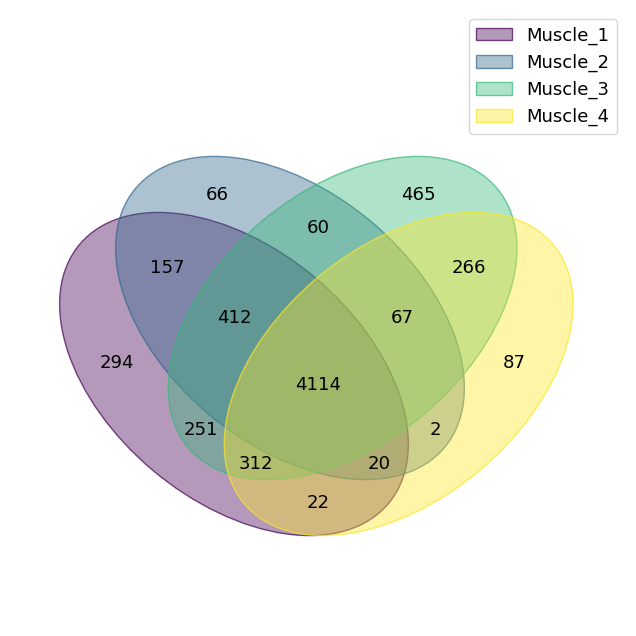

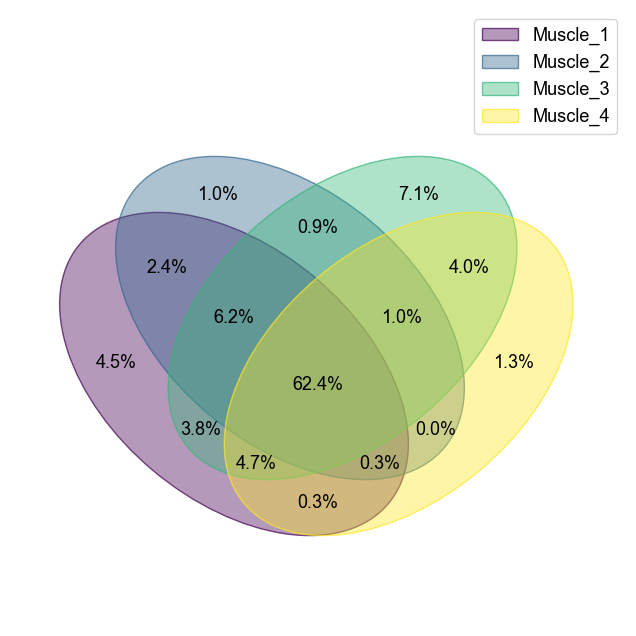

In [4]:
#Venn diagram without TOMOseq filter
samples = {
    "Muscle_1": set(list(data_genes_filtered_normal['Muscle_1'].index)),
    "Muscle_2": set(list(data_genes_filtered_normal['Muscle_2'].index)), 
    "Muscle_3": set(list(data_genes_filtered_normal['Muscle_3'].index)), 
    "Muscle_4": set(list(data_genes_filtered_normal['Muscle_4'].index)),
}

venn(samples)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 7
plt.savefig('Venn_Ngenes.svg', format = 'svg', dpi=300, bbox_inches='tight')   
plt.show()
plt.close()
venn(samples, fmt="{percentage:.1f}%")
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 7
plt.savefig('Venn_Pgenes.svg', format = 'svg', dpi=300, bbox_inches='tight')   
plt.show()
plt.close()

In [5]:
pd.DataFrame.from_dict(samples, orient='index').T.to_excel("data_venn.xlsx")

In [6]:
#calculate the szcores
data_zscores = zscores(data_genes_filtered_normal)



In [7]:
data_zscores_re={}
for key in data_zscores:
    data_zscores_re[key] = data_zscores[key].add_suffix('_'+key)
    print(key, len(list(data_zscores[key].columns)))
data_zscores_re[key]

Muscle_1 37
Muscle_2 45
Muscle_3 46
Muscle_4 43


,001_Muscle_4,002_Muscle_4,003_Muscle_4,004_Muscle_4,005_Muscle_4,006_Muscle_4,007_Muscle_4,008_Muscle_4,009_Muscle_4,010_Muscle_4,...,034_Muscle_4,035_Muscle_4,036_Muscle_4,037_Muscle_4,038_Muscle_4,039_Muscle_4,040_Muscle_4,041_Muscle_4,042_Muscle_4,043_Muscle_4
new_gene,,,,,,,,,,,,,,,,,,,,,
ENSMUSG00000000031_H19_lincRNA,0.530953,0.160581,0.932760,2.027773,1.276972,1.551331,1.133426,0.669879,0.005091,-0.569689,...,-0.578593,0.056750,-0.731108,-0.960546,-1.498720,-1.408764,-1.641116,-0.948101,-1.387627,-1.633279
ENSMUSG00000000056_Narf_ProteinCoding,-0.615313,0.369567,1.278004,1.258545,0.760358,-0.824214,0.610689,0.356962,0.212571,0.468193,...,0.087853,0.151041,0.082138,2.671023,-0.207273,-0.676242,0.236854,1.493310,-1.812568,0.409994
ENSMUSG00000000078_Klf6_ProteinCoding,-1.562245,-1.181947,-0.583298,1.785380,-0.217032,-0.700582,0.550389,-0.427664,-0.091134,-0.071125,...,-1.010242,-0.135831,0.089590,1.655639,0.304012,-0.076062,-0.133045,-0.121538,-1.562245,-0.593531
ENSMUSG00000000085_Scmh1_ProteinCoding,-1.433953,-0.819454,-0.247735,-0.353168,0.739689,-1.433953,0.271629,1.622287,0.467472,0.172121,...,0.796727,-0.512351,1.235139,-0.692246,0.827443,-0.633673,-0.856826,-1.433953,0.165468,0.131329
ENSMUSG00000000088_Cox5a_ProteinCoding,-1.565216,1.260661,1.862015,0.669165,1.263980,1.496008,0.941684,0.918969,-1.718102,-0.682064,...,-1.086149,-0.628412,-0.419655,0.006237,-1.576636,-0.237289,0.321356,-1.036786,-1.592442,-1.000548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000115987_Vps28_ProteinCoding,-1.577749,0.235319,1.277714,1.246685,-0.085616,0.344286,0.425157,1.523837,0.179432,0.484114,...,-0.517616,-1.655741,-0.240864,-0.204803,-0.559841,0.471319,0.324568,-0.269880,-1.670882,-0.034082
ENSMUSG00000116590_AC154200.1_lincRNA,-2.592039,-0.440790,-0.569041,0.624357,0.909792,-0.474890,1.146220,-1.024769,0.061066,0.252302,...,0.502534,-0.290434,0.683417,0.305496,-1.333154,0.144836,1.707875,1.057282,2.407214,-0.239173
ENSMUSG00000117679_Apbb3_ProteinCoding,-0.364993,-0.221151,1.710767,-1.412773,0.080218,-1.058323,-1.127439,1.446131,0.266171,0.295725,...,-1.091363,-0.221419,1.021416,0.128268,0.160433,-1.175153,0.204269,-0.842837,-1.906677,-1.906677


In [8]:
df1 = pd.concat([data_zscores_re['Muscle_1'], data_zscores_re['Muscle_2']], axis=1)
df2 = pd.concat([df1, data_zscores_re['Muscle_3']], axis=1)

data_zscores_all={}
data_zscores_all['shared'] = pd.concat([df2, data_zscores_re['Muscle_4']], axis=1).dropna()

data_zscores_all['shared']

,001_Muscle_1,002_Muscle_1,003_Muscle_1,004_Muscle_1,005_Muscle_1,006_Muscle_1,007_Muscle_1,008_Muscle_1,009_Muscle_1,010_Muscle_1,...,034_Muscle_4,035_Muscle_4,036_Muscle_4,037_Muscle_4,038_Muscle_4,039_Muscle_4,040_Muscle_4,041_Muscle_4,042_Muscle_4,043_Muscle_4
new_gene,,,,,,,,,,,,,,,,,,,,,
ENSMUSG00000000031_H19_lincRNA,-1.036785,-0.373270,0.263263,0.569445,1.227004,1.785570,2.050725,1.350514,1.423106,0.857407,...,-0.578593,0.056750,-0.731108,-0.960546,-1.498720,-1.408764,-1.641116,-0.948101,-1.387627,-1.633279
ENSMUSG00000000056_Narf_ProteinCoding,1.138439,-0.706679,-1.571013,-1.300227,-0.139761,-0.907144,-0.071753,0.052491,-0.957634,0.739750,...,0.087853,0.151041,0.082138,2.671023,-0.207273,-0.676242,0.236854,1.493310,-1.812568,0.409994
ENSMUSG00000000078_Klf6_ProteinCoding,-0.892160,-1.732086,-1.133935,-0.327262,-0.268263,0.461843,1.067162,-0.813462,0.509182,-0.147337,...,-1.010242,-0.135831,0.089590,1.655639,0.304012,-0.076062,-0.133045,-0.121538,-1.562245,-0.593531
ENSMUSG00000000085_Scmh1_ProteinCoding,-0.546422,-1.798119,-1.088990,-0.296048,0.185970,1.272163,0.973714,0.452481,-0.097095,1.863267,...,0.796727,-0.512351,1.235139,-0.692246,0.827443,-0.633673,-0.856826,-1.433953,0.165468,0.131329
ENSMUSG00000000088_Cox5a_ProteinCoding,0.213081,0.271711,1.208961,0.823092,-0.411594,1.069682,-0.353025,1.699342,0.639691,1.615704,...,-1.086149,-0.628412,-0.419655,0.006237,-1.576636,-0.237289,0.321356,-1.036786,-1.592442,-1.000548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000113902_Ndufb1.ps_ProteinCoding,0.759145,-1.421242,-0.333022,-0.815569,0.281813,0.159224,-1.379345,-1.472183,0.544841,2.695559,...,-0.457494,-1.173341,0.174368,-0.698569,0.188963,-0.120522,-2.388060,-0.971074,-1.441038,-0.529343
ENSMUSG00000115987_Vps28_ProteinCoding,-0.194923,1.037764,-2.126330,-0.859483,-1.117924,0.457893,0.083101,0.698913,-0.357334,-1.936309,...,-0.517616,-1.655741,-0.240864,-0.204803,-0.559841,0.471319,0.324568,-0.269880,-1.670882,-0.034082
ENSMUSG00000116590_AC154200.1_lincRNA,2.502420,0.237031,-1.302481,0.392095,-1.564440,0.275353,0.730918,-0.627430,-0.177413,1.802358,...,0.502534,-0.290434,0.683417,0.305496,-1.333154,0.144836,1.707875,1.057282,2.407214,-0.239173


In [9]:
data_zscores['Muscle_1'].shape, data_zscores['Muscle_2'].shape, data_zscores['Muscle_3'].shape, data_zscores['Muscle_4'].shape, data_zscores_all['shared'].shape


((5582, 37), (4898, 45), (5947, 46), (4890, 43), (4114, 171))

In [10]:
d = {'Section': [i for i in data_zscores['Muscle_1'].columns.values]+[i for i in data_zscores['Muscle_2'].columns.values]+[i for i in data_zscores['Muscle_3'].columns.values]+[i for i in data_zscores['Muscle_4'].columns.values], 
     'Sample': list(['Muscle_1']*37+['Muscle_2']*45+['Muscle_3']*46+['Muscle_4']*43), 
     'Region': list(['Proximal']*4+['Transition']*3+['Central']*17+['Transition']*6+['Distal']*7+['Transition']*5+['Central']*22+['Transition']*7+['Distal']*11+['Proximal']*6+['Transition']*2+['Central']*20+['Transition']*6+['Distal']*12+['Proximal']*4+['Transition']*6+['Central']*20+['Transition']*6+['Distal']*7)}
df_obs_all = pd.DataFrame(d)
df_obs_all

,Section,Sample,Region
0,001,Muscle_1,Proximal
1,002,Muscle_1,Proximal
2,003,Muscle_1,Proximal
3,004,Muscle_1,Proximal
4,005,Muscle_1,Transition
...,...,...,...
166,039,Muscle_4,Distal
167,040,Muscle_4,Distal
168,041,Muscle_4,Distal
169,042,Muscle_4,Distal


In [11]:
d = {'gene_id': list(data_zscores_all['shared'].index.values), 'gene_name': [i.split('_')[1] for i in data_zscores_all['shared'].index.values]}
df_var_all = pd.DataFrame(d)
df_var_all


,gene_id,gene_name
0,ENSMUSG00000000031_H19_lincRNA,H19
1,ENSMUSG00000000056_Narf_ProteinCoding,Narf
2,ENSMUSG00000000078_Klf6_ProteinCoding,Klf6
3,ENSMUSG00000000085_Scmh1_ProteinCoding,Scmh1
4,ENSMUSG00000000088_Cox5a_ProteinCoding,Cox5a
...,...,...
4109,ENSMUSG00000113902_Ndufb1.ps_ProteinCoding,Ndufb1.ps
4110,ENSMUSG00000115987_Vps28_ProteinCoding,Vps28
4111,ENSMUSG00000116590_AC154200.1_lincRNA,AC154200.1
4112,ENSMUSG00000117924_Tmem223_ProteinCoding,Tmem223


In [12]:
adata = ad.AnnData(X=np.array(data_zscores_all['shared'].T),
                        obs=df_obs_all,
                        var=df_var_all)
adata.var_names = adata.var['gene_id']
adata

/Users/claramartinezmir/venv/base-env-DMD/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/claramartinezmir/venv/base-env-DMD/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 171 × 4114
    obs: 'Section', 'Sample', 'Region'
    var: 'gene_id', 'gene_name'

In [13]:
rnd_vars = []
for i in range(5):
    print('randomization ',str(i))
    v = adata.X.reshape(adata.shape[0]*adata.shape[1])
    np.random.shuffle(v)
    v = v.reshape(adata.X.shape)
    V = np.cov(v.T)
    eigval, eigvec = np.linalg.eig(V)
    rnd_vars.append(eigval)
    

randomization  0


KeyboardInterrupt: 

In [13]:
adata = ad.AnnData(X=np.array(data_zscores_all['shared'].T),
                        obs=df_obs_all,
                        var=df_var_all)
adata.var_names = adata.var['gene_id']
sc.tl.pca(adata, svd_solver='arpack', n_comps = min([min(adata.shape)-1,5050]))
adata

/Users/claramartinezmir/venv/base-env-DMD/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/claramartinezmir/venv/base-env-DMD/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 171 × 4114
    obs: 'Section', 'Sample', 'Region'
    var: 'gene_id', 'gene_name'
    uns: 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [ ]:
#calculate the statistics of the random sample
rnd_mean = [np.mean([x[i] for x in rnd_vars]) for i in range(len(rnd_vars[0]))]
rnd_stderr = [np.std([x[i] for x in rnd_vars])/np.sqrt(len(rnd_vars)-1) for i in range(len(rnd_vars[0]))]
rnd_max = [np.max([x[i] for x in rnd_vars]) for i in range(len(rnd_vars[0]))]
var_th = rnd_mean[np.array(rnd_mean).argmax()] + rnd_stderr[np.array(rnd_stderr).argmax()]
npca = max([(adata.uns['pca']['variance']>1.2*var_th).sum(),5])
fraction_rnd_var=[rnd_vars[0]/sum(rnd_vars[0])*100, rnd_vars[1]/sum(rnd_vars[1])*100, rnd_vars[2]/sum(rnd_vars[2])*100, rnd_vars[3]/sum(rnd_vars[3])*100, rnd_vars[4]/sum(rnd_vars[4])*100]
fra_rnd_mean = [np.mean([x[i] for x in fraction_rnd_var]) for i in range(len(fraction_rnd_var[0]))]
fra_rnd_stderr = [np.std([x[i] for x in fraction_rnd_var])/np.sqrt(len(fraction_rnd_var)-1) for i in range(len(fraction_rnd_var[0]))]


In [ ]:
data_pca=pd.DataFrame(columns=['component','perc_variance','rnd_perc_var_mean','rnd_perc_var_sterr'])
data_pca['component']=np.arange(1,56)
data_pca['perc_variance']=adata.uns['pca']['variance'][0:55]/sum(adata.uns['pca']['variance'])*100
data_pca['rnd_perc_var_mean']=fra_rnd_mean[0:55]
data_pca['rnd_perc_var_sterr']=fra_rnd_stderr[0:55]
data_pca.to_excel("data_pca.xlsx") 
data_pca

In [ ]:
sc.set_figure_params(scanpy=True, fontsize=14)
fig, ax = plt.subplots(figsize=(4,4))
ax.scatter(np.arange(1, len(adata.uns['pca']['variance'])+1), adata.uns['pca']['variance']/sum(adata.uns['pca']['variance'])*100, s = 5, label = 'data')
ax.errorbar(np.arange(1,len(rnd_vars[0])+1), fra_rnd_mean, yerr = fra_rnd_stderr, color = 'red', label = 'mean randomized')
ax.text(npca, 0.5*((adata.uns['pca']['variance']/sum(adata.uns['pca']['variance'])*100).max()+(adata.uns['pca']['variance']/sum(adata.uns['pca']['variance'])*100).min()), ' '+str(npca), ha = 'left', fontsize=14, fontname="Microsoft Sans Serif")
ax.axvline(npca, ls = '--', c = 'k') 
ax.set_xlim(-5,min([3*npca, len(rnd_vars[0])+1])+10)
ax.set_ylabel('Percentage of variance', fontsize=14, fontname="Arial")
ax.legend()
plt.xlabel('Component', fontsize=14, fontname="Arial")
plt.xticks(fontsize=14, fontname="Arial")
plt.yticks(fontsize=14, fontname="Arial")
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Arial"
plt.savefig('pca_variance.svg', format = 'svg', dpi=300, bbox_inches='tight')  
plt.show()
plt.close()


## Leiden clustering

<Axes: title={'center': 'Leiden clusters'}, xlabel='PC1 (3.97%)', ylabel='PC2 (3.32%)'>

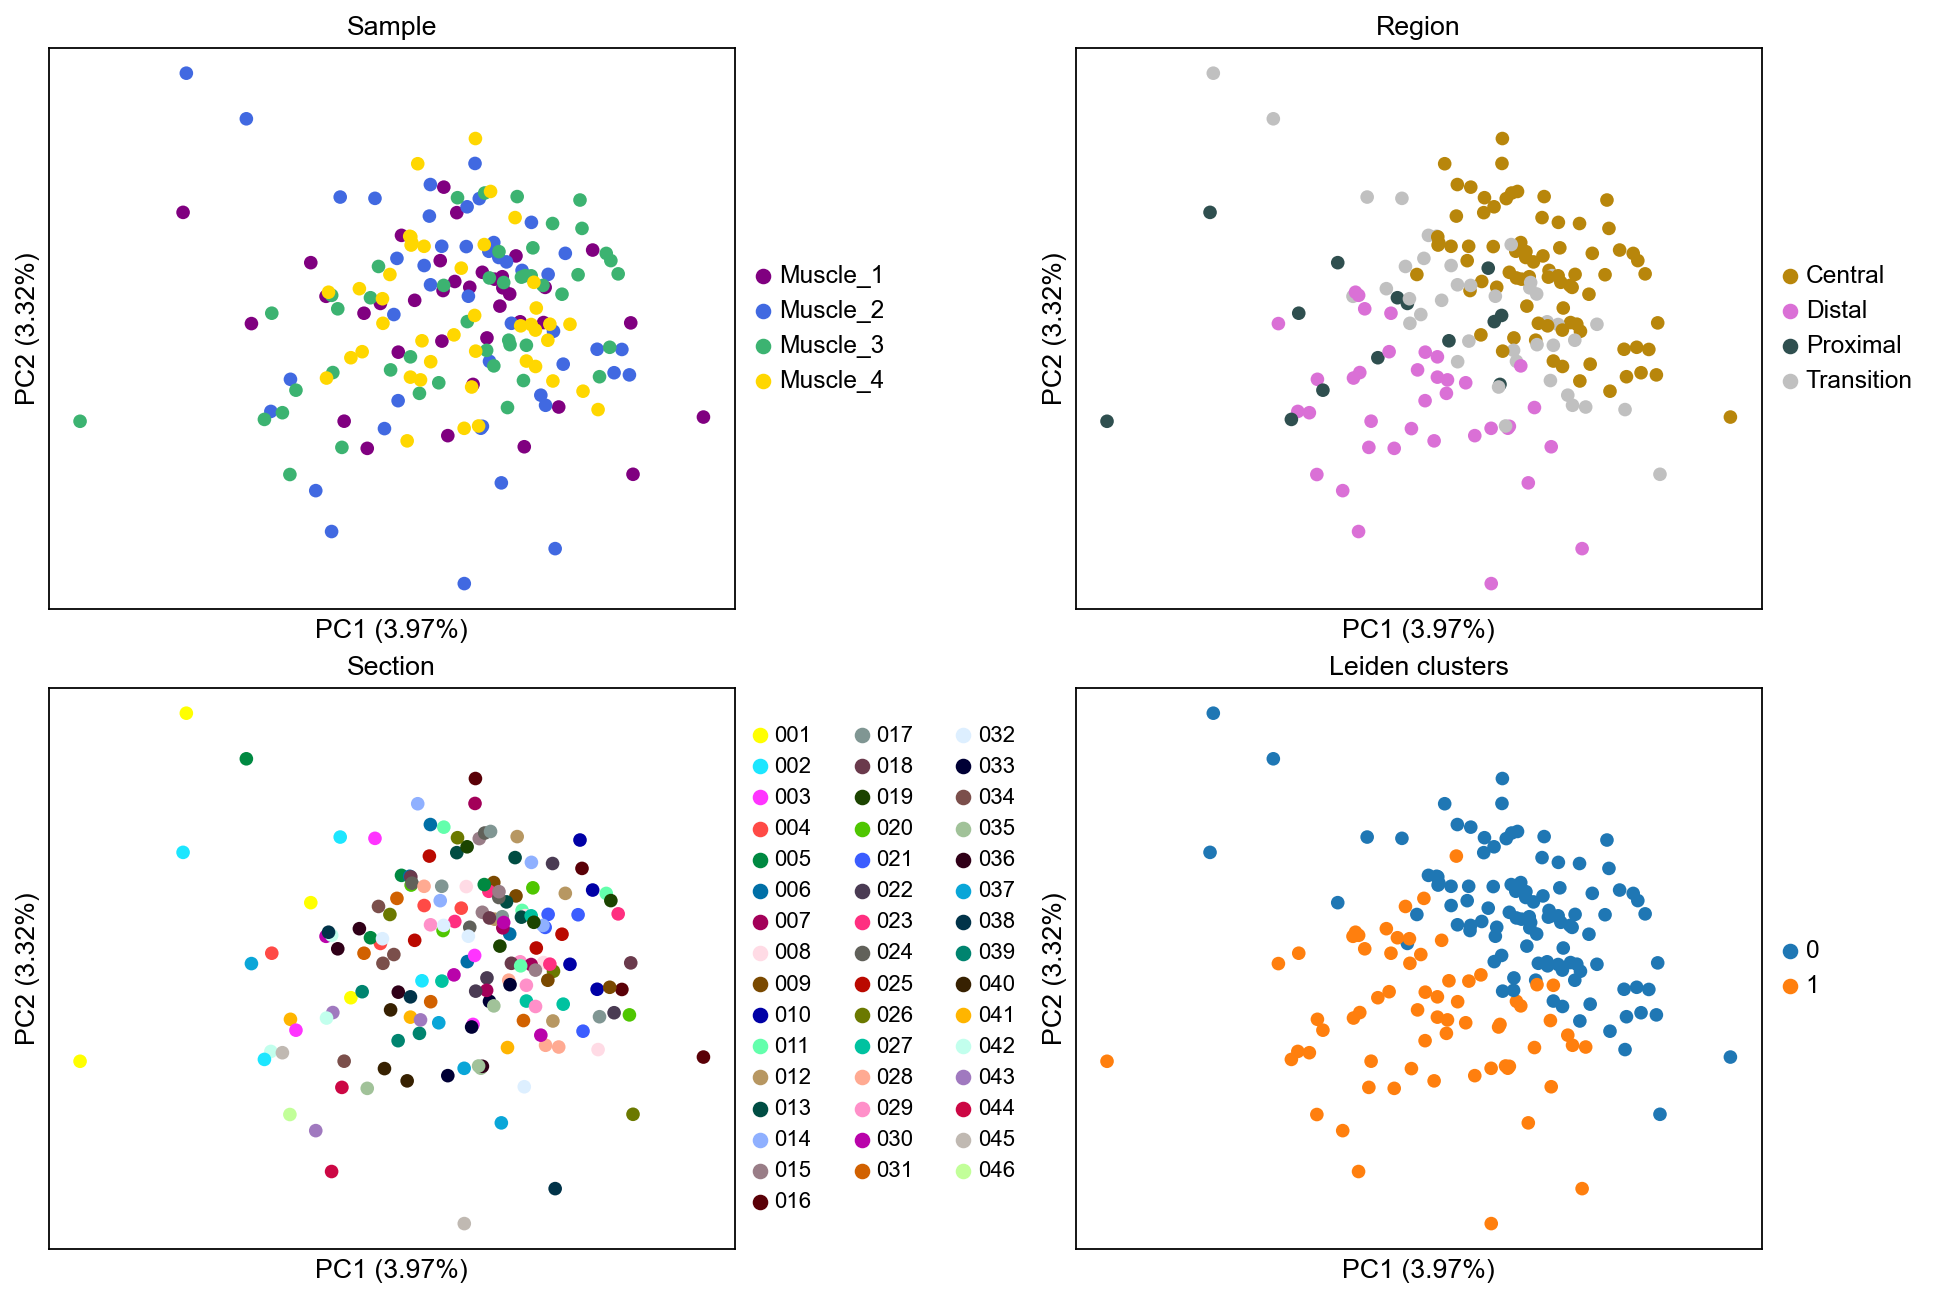

In [15]:

sc.set_figure_params(scanpy=True, fontsize=12, figsize=(1.5,1.5), color_map='Spectral_r')
fig, axs = plt.subplots(2, 2, figsize=(12,8),constrained_layout=True)
adata_plot = adata
adata_plot.obs['Section'] = adata_plot.obs['Section'].astype("category") # legend on data only works if the pandas column is categorical


sc.pl.pca(adata, components = ['1,2'], color='Sample', palette=['purple', 'royalblue', 'mediumseagreen', 'gold'], annotate_var_explained=True, ax=axs[0,0], show=False, size=150)
sc.pl.pca(adata, components = ['1,2'], color=['Region'], annotate_var_explained=True, palette=['darkgoldenrod', 'orchid', 'darkslategrey', 'silver'], ax=axs[0,1], show=False, size=150)
sc.pl.pca(adata_plot, components = ['1,2'], color='Section', legend_fontsize=10, color_map='Spectral_r', annotate_var_explained=True, ax=axs[1,0], show=False, size=150)

#neighbors and leiden cluster
sc.pp.neighbors(adata, n_neighbors = 65, n_pcs = 16)
sc.tl.leiden(adata, resolution = 0.5)

sc.pl.pca(adata, components = ['1,2'], color="leiden", title="Leiden clusters", ax=axs[1,1], show=False, size=150, annotate_var_explained=True)





In [16]:

#rename clusters
new_cluster_names = [
    'Central',
    'Proximal-distal'
    ]
adata.rename_categories('leiden', new_cluster_names)

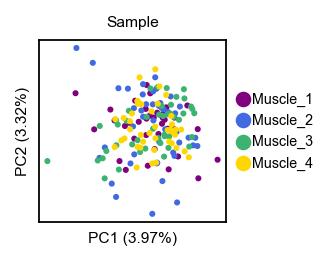

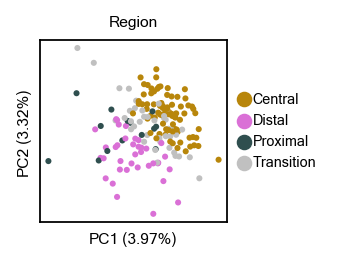

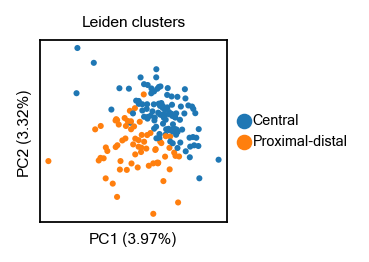

In [17]:
sc.set_figure_params(fontsize=7, figsize=(1.5,1.5), color_map='Spectral_r')
sc.pl.pca(adata, components = ['1,2'], color='Sample', palette=['purple', 'royalblue', 'mediumseagreen', 'gold'], annotate_var_explained=True, size=30, return_fig=True)
plt.gcf()
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig('PC_sample.svg', format = 'svg', dpi=300, bbox_inches='tight')   
plt.show()

sc.pl.pca(adata, components = ['1,2'], color=['Region'], annotate_var_explained=True, palette=['darkgoldenrod', 'orchid', 'darkslategrey', 'silver'], size=30, return_fig=True)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig('PC_region.svg', format = 'svg', dpi=300, bbox_inches='tight')   
plt.show()

sc.pl.pca(adata, components = ['1,2'], color="leiden", title="Leiden clusters", size=30, annotate_var_explained=True, return_fig=True)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig('PC_cluster.svg', format = 'svg', dpi=300, bbox_inches='tight')   
plt.show()


In [18]:
#access de data
#Create a variable list with the file names and one with the labels to use as dictionary keys
path = ''

file_names = [path + 'Muscle_1_genes.t.t.counts_filtered_noRibo_TOMOseq2-4.tsv.gz', 
             path + 'Muscle_2_genes.t.t.counts_filtered_noRibo_TOMOseq2-4.tsv.gz',
              path + 'Muscle_3_genes.t.t.counts_filtered_noRibo_TOMOseq2-4.tsv.gz', 
             path + 'Muscle_4_genes.t.t.counts_filtered_noRibo_TOMOseq2-4.tsv.gz']

labels = ['Muscle_1', 'Muscle_2','Muscle_3', 'Muscle_4']

#use accessData() function to obtain a dictonary with each dataset with labels as key
data_genes_filtered = accessData(file_names, labels)


In [19]:
meta_data=pd.DataFrame(adata.obs)
meta_data['Transcript counts'] = list(data_genes_filtered['Muscle_1'].sum())+list(data_genes_filtered['Muscle_2'].sum())+list(data_genes_filtered['Muscle_3'].sum())+list(data_genes_filtered['Muscle_4'].sum())
meta_data['PC1'] = list(pd.DataFrame(adata.obsm['X_pca']).iloc[:,0])
meta_data['PC2'] = list(pd.DataFrame(adata.obsm['X_pca']).iloc[:,0])
meta_data.to_excel("metadata.xlsx") 
meta_data

,Section,Sample,Region,leiden,Transcript counts,PC1,PC2
0,001,Muscle_1,Proximal,Central,161211.575240,-19.433060,-19.433060
1,002,Muscle_1,Proximal,Central,188609.317165,-35.949142,-35.949142
2,003,Muscle_1,Proximal,Proximal-distal,285859.890922,1.548404,1.548404
3,004,Muscle_1,Proximal,Central,603433.080500,-10.428934,-10.428934
4,005,Muscle_1,Transition,Central,462816.711656,-7.703436,-7.703436
...,...,...,...,...,...,...,...
166,039,Muscle_4,Distal,Proximal-distal,348027.897739,-12.789564,-12.789564
167,040,Muscle_4,Distal,Proximal-distal,582268.965080,-6.970232,-6.970232
168,041,Muscle_4,Distal,Proximal-distal,201367.900503,-6.545357,-6.545357
169,042,Muscle_4,Distal,Proximal-distal,160966.128144,-17.398216,-17.398216


## Analisis correlations sections from all 4 muscles


In [20]:
#calculate the szcores
data_zscores = zscores(data_genes_filtered_normal)


In [21]:
data_zscores_re={}
for key in data_zscores:
    data_zscores_re[key] = data_zscores[key].add_suffix('_'+key)
    print(key, len(list(data_zscores[key].columns)))
data_zscores_re[key]

Muscle_1 37
Muscle_2 45
Muscle_3 46
Muscle_4 43


,001_Muscle_4,002_Muscle_4,003_Muscle_4,004_Muscle_4,005_Muscle_4,006_Muscle_4,007_Muscle_4,008_Muscle_4,009_Muscle_4,010_Muscle_4,...,034_Muscle_4,035_Muscle_4,036_Muscle_4,037_Muscle_4,038_Muscle_4,039_Muscle_4,040_Muscle_4,041_Muscle_4,042_Muscle_4,043_Muscle_4
new_gene,,,,,,,,,,,,,,,,,,,,,
ENSMUSG00000000031_H19_lincRNA,0.530953,0.160581,0.932760,2.027773,1.276972,1.551331,1.133426,0.669879,0.005091,-0.569689,...,-0.578593,0.056750,-0.731108,-0.960546,-1.498720,-1.408764,-1.641116,-0.948101,-1.387627,-1.633279
ENSMUSG00000000056_Narf_ProteinCoding,-0.615313,0.369567,1.278004,1.258545,0.760358,-0.824214,0.610689,0.356962,0.212571,0.468193,...,0.087853,0.151041,0.082138,2.671023,-0.207273,-0.676242,0.236854,1.493310,-1.812568,0.409994
ENSMUSG00000000078_Klf6_ProteinCoding,-1.562245,-1.181947,-0.583298,1.785380,-0.217032,-0.700582,0.550389,-0.427664,-0.091134,-0.071125,...,-1.010242,-0.135831,0.089590,1.655639,0.304012,-0.076062,-0.133045,-0.121538,-1.562245,-0.593531
ENSMUSG00000000085_Scmh1_ProteinCoding,-1.433953,-0.819454,-0.247735,-0.353168,0.739689,-1.433953,0.271629,1.622287,0.467472,0.172121,...,0.796727,-0.512351,1.235139,-0.692246,0.827443,-0.633673,-0.856826,-1.433953,0.165468,0.131329
ENSMUSG00000000088_Cox5a_ProteinCoding,-1.565216,1.260661,1.862015,0.669165,1.263980,1.496008,0.941684,0.918969,-1.718102,-0.682064,...,-1.086149,-0.628412,-0.419655,0.006237,-1.576636,-0.237289,0.321356,-1.036786,-1.592442,-1.000548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000115987_Vps28_ProteinCoding,-1.577749,0.235319,1.277714,1.246685,-0.085616,0.344286,0.425157,1.523837,0.179432,0.484114,...,-0.517616,-1.655741,-0.240864,-0.204803,-0.559841,0.471319,0.324568,-0.269880,-1.670882,-0.034082
ENSMUSG00000116590_AC154200.1_lincRNA,-2.592039,-0.440790,-0.569041,0.624357,0.909792,-0.474890,1.146220,-1.024769,0.061066,0.252302,...,0.502534,-0.290434,0.683417,0.305496,-1.333154,0.144836,1.707875,1.057282,2.407214,-0.239173
ENSMUSG00000117679_Apbb3_ProteinCoding,-0.364993,-0.221151,1.710767,-1.412773,0.080218,-1.058323,-1.127439,1.446131,0.266171,0.295725,...,-1.091363,-0.221419,1.021416,0.128268,0.160433,-1.175153,0.204269,-0.842837,-1.906677,-1.906677


In [22]:
data_zscores_all={}
df1 = pd.concat([data_zscores_re['Muscle_1'], data_zscores_re['Muscle_2']], axis=1)
df2 = pd.concat([df1, data_zscores_re['Muscle_3']], axis=1).dropna()
data_zscores_all['shared'] = pd.concat([df2, data_zscores_re['Muscle_4']], axis=1).dropna()

data_zscores_all['shared']

,001_Muscle_1,002_Muscle_1,003_Muscle_1,004_Muscle_1,005_Muscle_1,006_Muscle_1,007_Muscle_1,008_Muscle_1,009_Muscle_1,010_Muscle_1,...,034_Muscle_4,035_Muscle_4,036_Muscle_4,037_Muscle_4,038_Muscle_4,039_Muscle_4,040_Muscle_4,041_Muscle_4,042_Muscle_4,043_Muscle_4
new_gene,,,,,,,,,,,,,,,,,,,,,
ENSMUSG00000000031_H19_lincRNA,-1.036785,-0.373270,0.263263,0.569445,1.227004,1.785570,2.050725,1.350514,1.423106,0.857407,...,-0.578593,0.056750,-0.731108,-0.960546,-1.498720,-1.408764,-1.641116,-0.948101,-1.387627,-1.633279
ENSMUSG00000000056_Narf_ProteinCoding,1.138439,-0.706679,-1.571013,-1.300227,-0.139761,-0.907144,-0.071753,0.052491,-0.957634,0.739750,...,0.087853,0.151041,0.082138,2.671023,-0.207273,-0.676242,0.236854,1.493310,-1.812568,0.409994
ENSMUSG00000000078_Klf6_ProteinCoding,-0.892160,-1.732086,-1.133935,-0.327262,-0.268263,0.461843,1.067162,-0.813462,0.509182,-0.147337,...,-1.010242,-0.135831,0.089590,1.655639,0.304012,-0.076062,-0.133045,-0.121538,-1.562245,-0.593531
ENSMUSG00000000085_Scmh1_ProteinCoding,-0.546422,-1.798119,-1.088990,-0.296048,0.185970,1.272163,0.973714,0.452481,-0.097095,1.863267,...,0.796727,-0.512351,1.235139,-0.692246,0.827443,-0.633673,-0.856826,-1.433953,0.165468,0.131329
ENSMUSG00000000088_Cox5a_ProteinCoding,0.213081,0.271711,1.208961,0.823092,-0.411594,1.069682,-0.353025,1.699342,0.639691,1.615704,...,-1.086149,-0.628412,-0.419655,0.006237,-1.576636,-0.237289,0.321356,-1.036786,-1.592442,-1.000548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000113902_Ndufb1.ps_ProteinCoding,0.759145,-1.421242,-0.333022,-0.815569,0.281813,0.159224,-1.379345,-1.472183,0.544841,2.695559,...,-0.457494,-1.173341,0.174368,-0.698569,0.188963,-0.120522,-2.388060,-0.971074,-1.441038,-0.529343
ENSMUSG00000115987_Vps28_ProteinCoding,-0.194923,1.037764,-2.126330,-0.859483,-1.117924,0.457893,0.083101,0.698913,-0.357334,-1.936309,...,-0.517616,-1.655741,-0.240864,-0.204803,-0.559841,0.471319,0.324568,-0.269880,-1.670882,-0.034082
ENSMUSG00000116590_AC154200.1_lincRNA,2.502420,0.237031,-1.302481,0.392095,-1.564440,0.275353,0.730918,-0.627430,-0.177413,1.802358,...,0.502534,-0.290434,0.683417,0.305496,-1.333154,0.144836,1.707875,1.057282,2.407214,-0.239173


In [23]:
data_corr_all={}
for key in data_zscores_all:
    dataframe=data_zscores_all[key].astype(float)
    data_corr_all[key] = dataframe.corr()
data_corr_all['shared'].to_excel("data_correlations.xlsx") 
data_corr_all['shared']

,001_Muscle_1,002_Muscle_1,003_Muscle_1,004_Muscle_1,005_Muscle_1,006_Muscle_1,007_Muscle_1,008_Muscle_1,009_Muscle_1,010_Muscle_1,...,034_Muscle_4,035_Muscle_4,036_Muscle_4,037_Muscle_4,038_Muscle_4,039_Muscle_4,040_Muscle_4,041_Muscle_4,042_Muscle_4,043_Muscle_4
001_Muscle_1,1.000000,0.007670,0.012907,-0.001847,-0.055567,-0.018624,-0.071920,-0.041480,-0.059568,-0.052409,...,-0.011708,-0.053579,-0.004378,0.023256,-0.040658,-0.020731,0.012421,0.001110,0.042994,-0.001414
002_Muscle_1,0.007670,1.000000,-0.025132,0.067789,0.032504,-0.017803,-0.014064,-0.045905,-0.035227,-0.067409,...,0.011872,-0.001875,-0.015698,-0.002104,0.029273,0.009600,-0.002952,-0.009957,0.021696,-0.000764
003_Muscle_1,0.012907,-0.025132,1.000000,0.010499,-0.048539,-0.061440,-0.078381,-0.037940,-0.045227,-0.069869,...,-0.020688,-0.028292,-0.053963,0.031285,-0.046090,-0.049167,0.006987,0.014541,0.013206,0.011664
004_Muscle_1,-0.001847,0.067789,0.010499,1.000000,0.042554,0.067851,0.006762,-0.055495,-0.006986,-0.058894,...,-0.008124,0.036834,-0.040249,0.013748,-0.011041,0.003538,0.014204,-0.017398,0.033418,-0.025379
005_Muscle_1,-0.055567,0.032504,-0.048539,0.042554,1.000000,0.072720,0.008642,-0.001578,0.028049,0.044823,...,0.028009,-0.030189,0.013810,-0.059437,0.034885,-0.004897,0.006008,-0.006012,-0.017053,-0.034129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
039_Muscle_4,-0.020731,0.009600,-0.049167,0.003538,-0.004897,0.012933,-0.012143,-0.012230,-0.017734,-0.028523,...,0.064947,-0.017764,0.021409,-0.009699,0.044835,1.000000,0.046673,0.023571,0.006103,0.019312
040_Muscle_4,0.012421,-0.002952,0.006987,0.014204,0.006008,-0.052248,-0.002236,-0.002182,-0.053180,-0.110791,...,0.055396,0.044372,-0.003995,0.075665,0.057090,0.046673,1.000000,0.032951,-0.003697,0.034374
041_Muscle_4,0.001110,-0.009957,0.014541,-0.017398,-0.006012,0.002280,-0.019885,-0.033175,-0.019138,-0.032667,...,-0.004022,-0.021266,0.007470,0.021462,0.005502,0.023571,0.032951,1.000000,-0.013258,0.011537
042_Muscle_4,0.042994,0.021696,0.013206,0.033418,-0.017053,-0.003166,-0.011182,-0.022354,-0.015664,-0.039482,...,0.023877,-0.028598,-0.007816,0.035561,0.014623,0.006103,-0.003697,-0.013258,1.000000,-0.000649


In [24]:
for index in data_corr_all['shared'].index:
    data_corr_all['shared'].loc[index,index] = 0
data_corr_all['shared']

,001_Muscle_1,002_Muscle_1,003_Muscle_1,004_Muscle_1,005_Muscle_1,006_Muscle_1,007_Muscle_1,008_Muscle_1,009_Muscle_1,010_Muscle_1,...,034_Muscle_4,035_Muscle_4,036_Muscle_4,037_Muscle_4,038_Muscle_4,039_Muscle_4,040_Muscle_4,041_Muscle_4,042_Muscle_4,043_Muscle_4
001_Muscle_1,0.000000,0.007670,0.012907,-0.001847,-0.055567,-0.018624,-0.071920,-0.041480,-0.059568,-0.052409,...,-0.011708,-0.053579,-0.004378,0.023256,-0.040658,-0.020731,0.012421,0.001110,0.042994,-0.001414
002_Muscle_1,0.007670,0.000000,-0.025132,0.067789,0.032504,-0.017803,-0.014064,-0.045905,-0.035227,-0.067409,...,0.011872,-0.001875,-0.015698,-0.002104,0.029273,0.009600,-0.002952,-0.009957,0.021696,-0.000764
003_Muscle_1,0.012907,-0.025132,0.000000,0.010499,-0.048539,-0.061440,-0.078381,-0.037940,-0.045227,-0.069869,...,-0.020688,-0.028292,-0.053963,0.031285,-0.046090,-0.049167,0.006987,0.014541,0.013206,0.011664
004_Muscle_1,-0.001847,0.067789,0.010499,0.000000,0.042554,0.067851,0.006762,-0.055495,-0.006986,-0.058894,...,-0.008124,0.036834,-0.040249,0.013748,-0.011041,0.003538,0.014204,-0.017398,0.033418,-0.025379
005_Muscle_1,-0.055567,0.032504,-0.048539,0.042554,0.000000,0.072720,0.008642,-0.001578,0.028049,0.044823,...,0.028009,-0.030189,0.013810,-0.059437,0.034885,-0.004897,0.006008,-0.006012,-0.017053,-0.034129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
039_Muscle_4,-0.020731,0.009600,-0.049167,0.003538,-0.004897,0.012933,-0.012143,-0.012230,-0.017734,-0.028523,...,0.064947,-0.017764,0.021409,-0.009699,0.044835,0.000000,0.046673,0.023571,0.006103,0.019312
040_Muscle_4,0.012421,-0.002952,0.006987,0.014204,0.006008,-0.052248,-0.002236,-0.002182,-0.053180,-0.110791,...,0.055396,0.044372,-0.003995,0.075665,0.057090,0.046673,0.000000,0.032951,-0.003697,0.034374
041_Muscle_4,0.001110,-0.009957,0.014541,-0.017398,-0.006012,0.002280,-0.019885,-0.033175,-0.019138,-0.032667,...,-0.004022,-0.021266,0.007470,0.021462,0.005502,0.023571,0.032951,0.000000,-0.013258,0.011537
042_Muscle_4,0.042994,0.021696,0.013206,0.033418,-0.017053,-0.003166,-0.011182,-0.022354,-0.015664,-0.039482,...,0.023877,-0.028598,-0.007816,0.035561,0.014623,0.006103,-0.003697,-0.013258,0.000000,-0.000649


In [25]:
colors=[]
data_clusters=adata.obs
for index in data_clusters.index:
    if data_clusters.loc[index]['leiden'] == 'Central':
        colors.append('tab:blue')
    if data_clusters.loc[index]['leiden'] == 'Proximal-distal':
        colors.append('tab:orange')
data_clusters['color']= colors
data_clusters

,Section,Sample,Region,leiden,color
0,001,Muscle_1,Proximal,Central,tab:blue
1,002,Muscle_1,Proximal,Central,tab:blue
2,003,Muscle_1,Proximal,Proximal-distal,tab:orange
3,004,Muscle_1,Proximal,Central,tab:blue
4,005,Muscle_1,Transition,Central,tab:blue
...,...,...,...,...,...
166,039,Muscle_4,Distal,Proximal-distal,tab:orange
167,040,Muscle_4,Distal,Proximal-distal,tab:orange
168,041,Muscle_4,Distal,Proximal-distal,tab:orange
169,042,Muscle_4,Distal,Proximal-distal,tab:orange


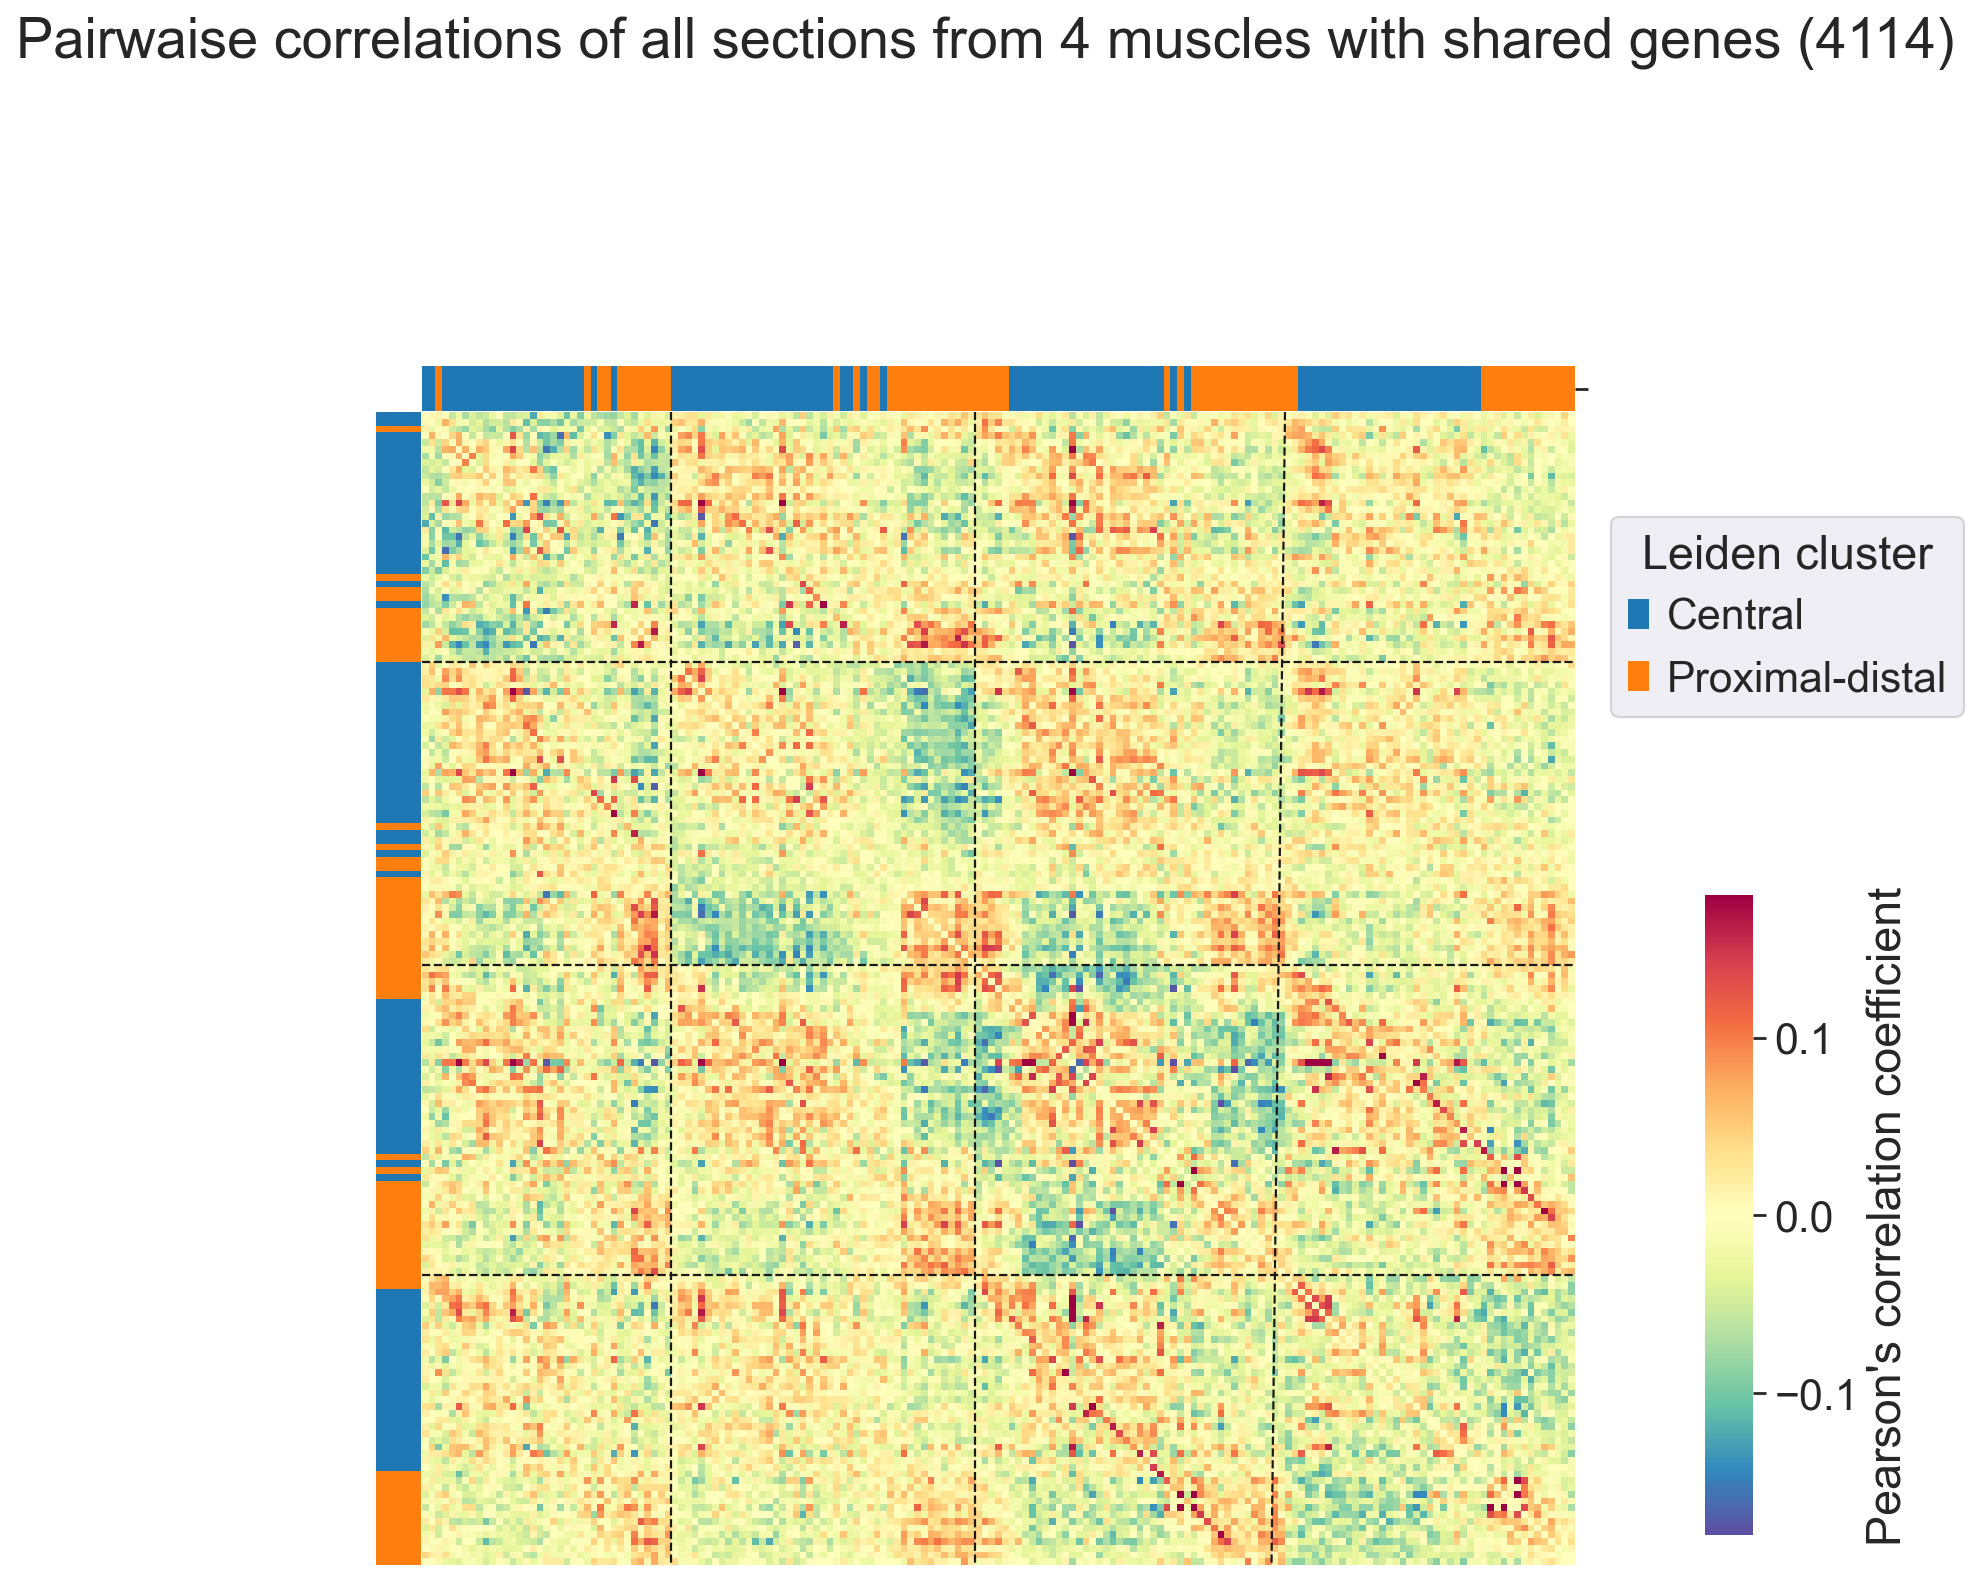

In [26]:
samples2=pd.Series(list(data_clusters['leiden']), index=list(np.arange(0,171)))
colors2=pd.Series(list(data_clusters['color']), index=list(np.arange(0,171)))
reference2 = {'Central': 'tab:blue', 'Proximal-distal': 'tab:orange'}

data_plot=data_corr_all['shared'].reset_index(drop=True)
data_plot.columns = list(np.arange(0,171))

sns.set(font_scale=1.75)

g = sns.clustermap(data_plot, row_cluster=False, col_cluster=False, row_colors = colors2, col_colors = colors2, cmap="Spectral_r", yticklabels=False, xticklabels=False, cbar_kws={'label': "Pearson's correlation coefficient"}, vmax=0.18, vmin=-0.18)
# Turn off the clustering
# Add colored class labels 
#add title and adjust color bar location
g.fig.suptitle('Pairwaise correlations of all sections from 4 muscles with shared genes (4114)', y=1, x=0.6)
g.ax_cbar.set_position((1.05, 0.05, .03, 0.4))

# add legends

for label in samples2.unique():
    g.ax_row_dendrogram.bar(0, 0, color=reference2[label], label=label, linewidth=0);
l2 = g.ax_row_dendrogram.legend(title='Leiden cluster', loc="upper right", ncol=1, bbox_to_anchor=(1.225, 0.7), bbox_transform=plt.gcf().transFigure)

#add lines delimiting muscles
ax = g.ax_heatmap  
#ax.plot([0, 171], [0, 0], 'w-', lw = 2)
ax.plot([0, 171], [37, 37], 'k--', lw = 1)
ax.plot([0, 171], [37+45, 37+45], 'k--', lw = 1)
ax.plot([0, 171], [37+45+46, 37+45+46], 'k--', lw = 1)

#ax.plot([0, 0], [0, 171], 'w-', lw = 1) 
ax.plot([37, 37], [0, 171], 'k--', lw = 1)
ax.plot([37+45, 37+45], [0, 171], 'k--', lw = 1)
ax.plot([37+45+46, 35+45+46], [0, 171], 'k--', lw = 1)

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.rcParams["font.size"] = 7
plt.savefig('Correlation_heatmap_all.svg', format = 'svg', dpi=300, bbox_inches='tight')  
plt.show()
plt.close()
 

/Users/claramartinezmir/venv/base-env2/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/claramartinezmir/venv/base-env2/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


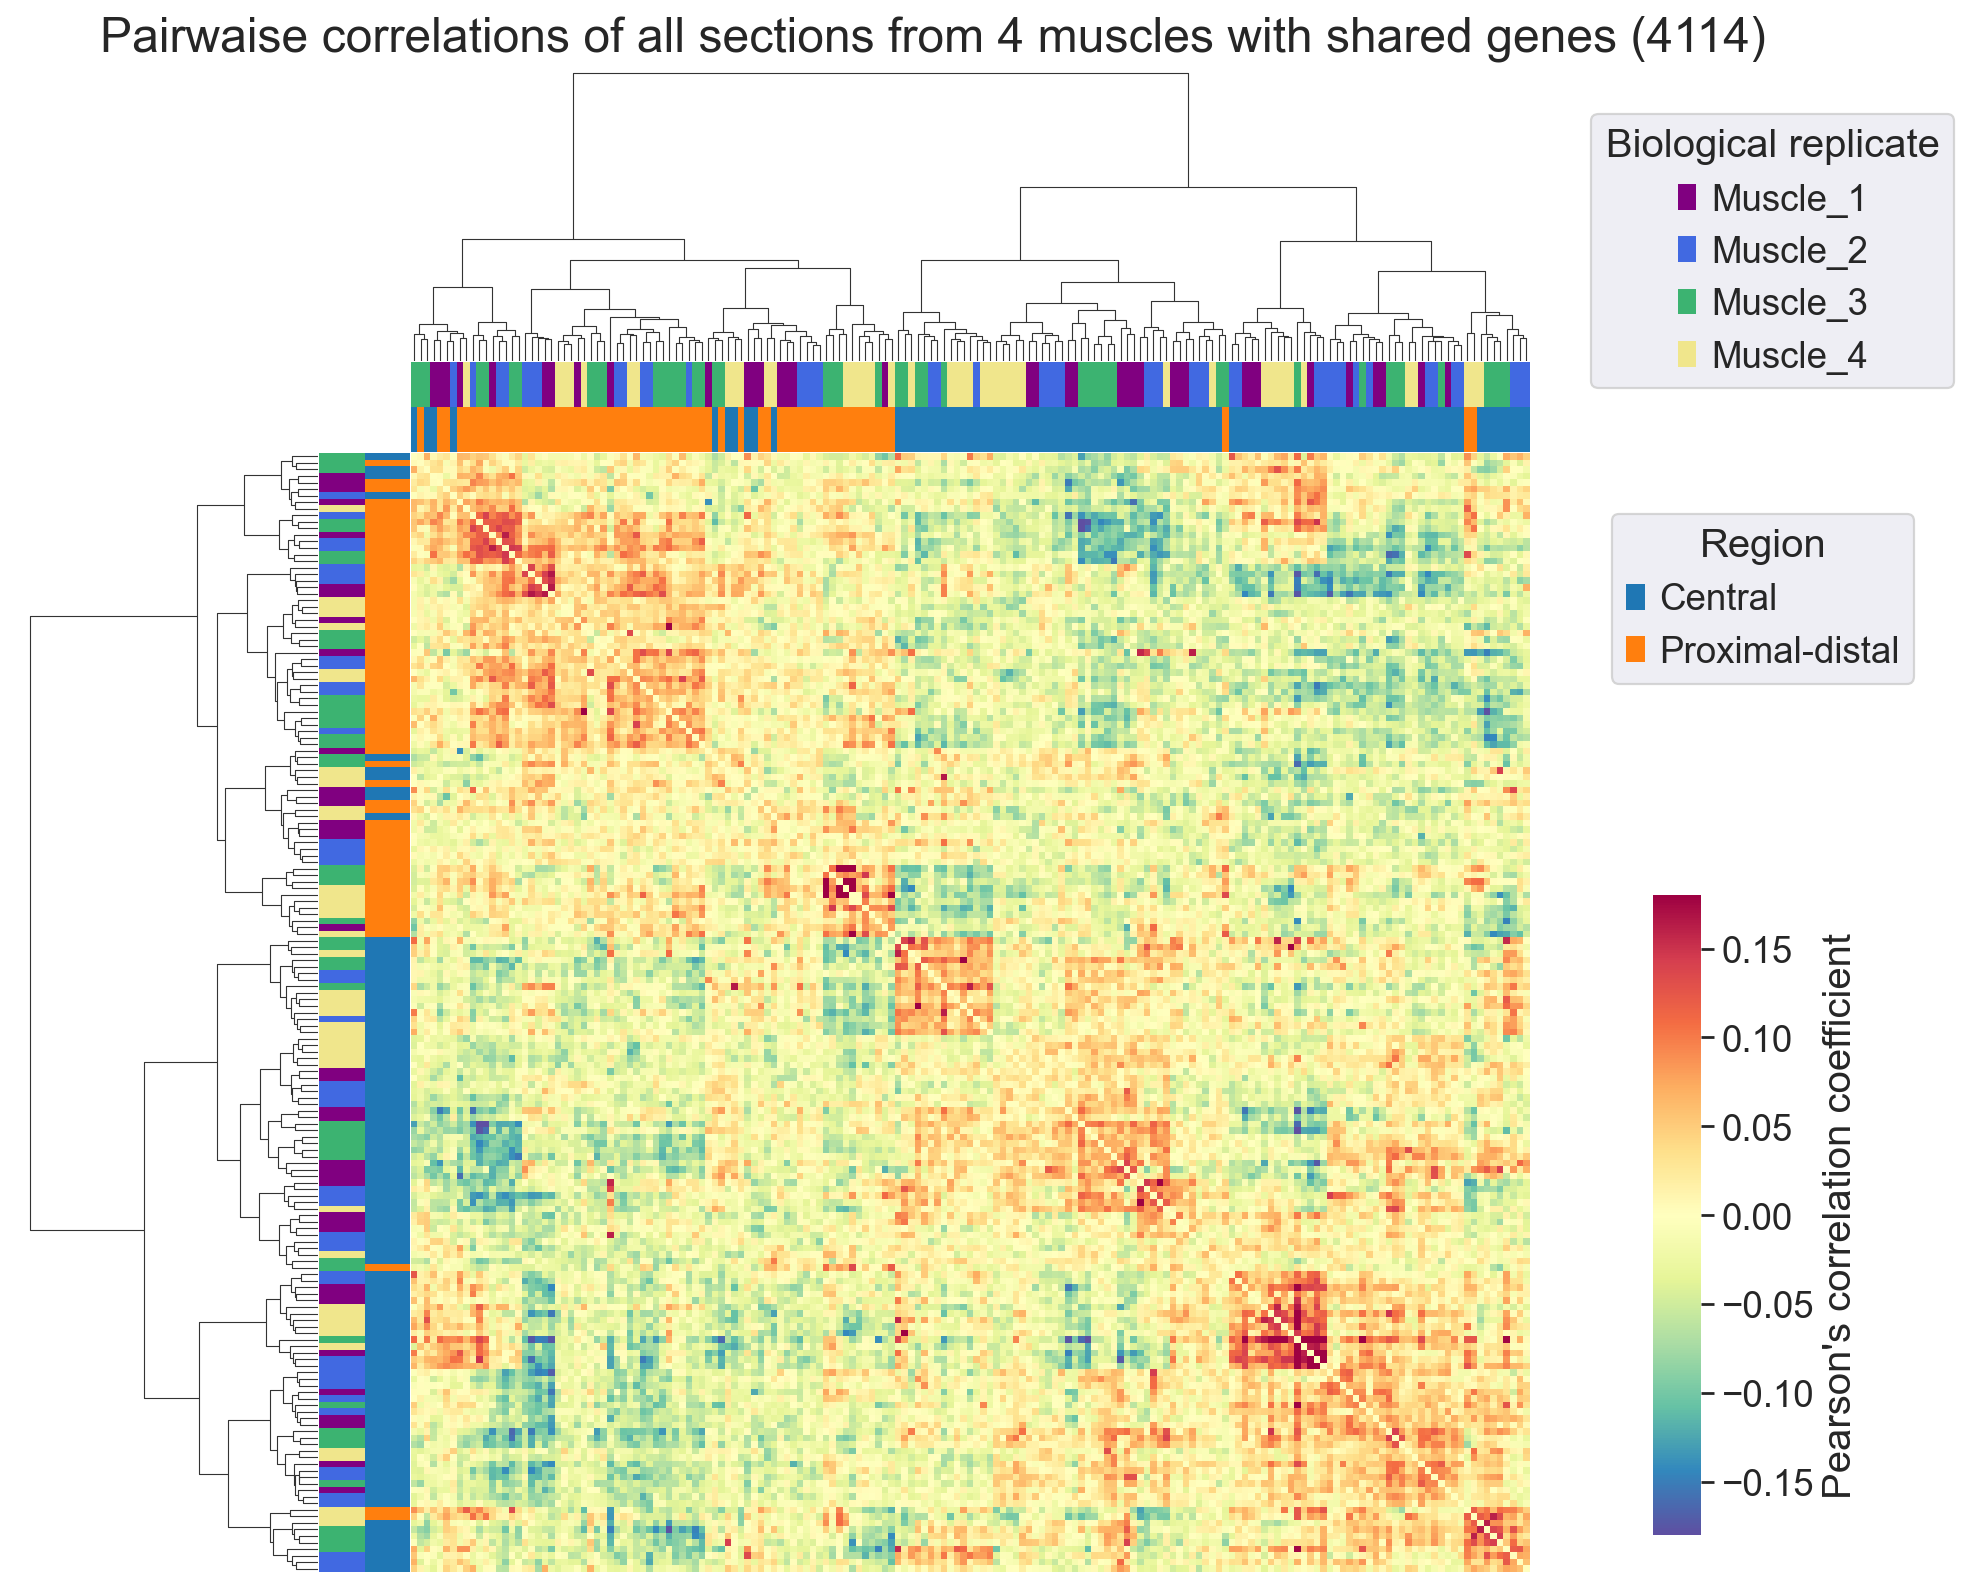

In [27]:
samples=pd.Series(list(['Muscle_1']*37+['Muscle_2']*45+['Muscle_3']*46+['Muscle_4']*43), index=list(np.arange(0,171)))
colors=pd.Series(list(['purple']*37+['royalblue']*45+['mediumseagreen']*46+['khaki']*43), index=list(np.arange(0,171)))

reference={'Muscle_1': 'purple', 'Muscle_2': 'royalblue', 'Muscle_3': 'mediumseagreen', 'Muscle_4': 'khaki'}

samples2=pd.Series(list(data_clusters['leiden']), index=list(np.arange(0,171)))
colors2=pd.Series(list(data_clusters['color']), index=list(np.arange(0,171)))
reference2 = {'Central': 'tab:blue', 'Proximal-distal': 'tab:orange'}

data_plot=data_corr_all['shared'].reset_index(drop=True)
data_plot.columns = list(np.arange(0,171))

sns.set(font="sans-serif", font_scale=1.5)

g = sns.clustermap(data_plot, method='ward', cmap='Spectral_r', row_colors = [colors, colors2], col_colors = [colors, colors2], yticklabels=False, xticklabels=False, cbar_kws={'label': "Pearson's correlation coefficient"}, vmax=0.18, vmin=-0.18)

# Turn off the clustering
# Add colored class labels 
#add title and adjust color bar location
g.fig.suptitle('Pairwaise correlations of all sections from 4 muscles with shared genes (4114)', y=1, x=0.6)
g.ax_cbar.set_position((1.05, 0.05, .03, 0.4))

# add legends
for label in samples.unique():
    g.ax_col_dendrogram.bar(0, 0, color=reference[label], label=label, linewidth=0);
l1 = g.ax_col_dendrogram.legend(title='Biological replicate', loc="upper right", ncol=1, bbox_to_anchor=(1.25, 0.95), bbox_transform=plt.gcf().transFigure)

for label in samples2.unique():
    g.ax_row_dendrogram.bar(0, 0, color=reference2[label], label=label, linewidth=0);
l2 = g.ax_row_dendrogram.legend(title='Region', loc="upper right", ncol=1, bbox_to_anchor=(1.225, 0.7), bbox_transform=plt.gcf().transFigure)

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 7
plt.savefig('Correlation_cluster_all.svg', format = 'svg', dpi=300, bbox_inches='tight')  
plt.show()
plt.close()


### Visualization of clusters on unfiltered data

In [29]:
data={}
data['Muscle_1']=pd.read_excel('data_filter_Muscle1.xlsx', index_col=0) 
data['Muscle_2']=pd.read_excel('data_filter_Muscle2.xlsx', index_col=0)
data['Muscle_3']=pd.read_excel('data_filter_Muscle3.xlsx', index_col=0)
data['Muscle_4']=pd.read_excel('data_filter_Muscle4.xlsx', index_col=0)

FileNotFoundError: [Errno 2] No such file or directory: 'data_filter_Muscle1.xlsx'

In [32]:
adata_1=adata[adata.obs["Sample"] == "Muscle_1"]
data_1=pd.DataFrame(adata_1.obs)
data_1=data_1.set_index('Section')

list_cluster=[]
list_color=[]

for index in data['Muscle_1'].index:
    if data['Muscle_1'].loc[index]['Filter'] == 'No':
        list_cluster.append('Filtered')
        list_color.append('grey')
    else:
        list_cluster.append(data_1.loc[data['Muscle_1'].loc[index]['Filter']]['leiden'])
        list_color.append(data_1.loc[data['Muscle_1'].loc[index]['Filter']]['color'])
data['Muscle_1']['leiden']=list_cluster
data['Muscle_1']['color']=list_color

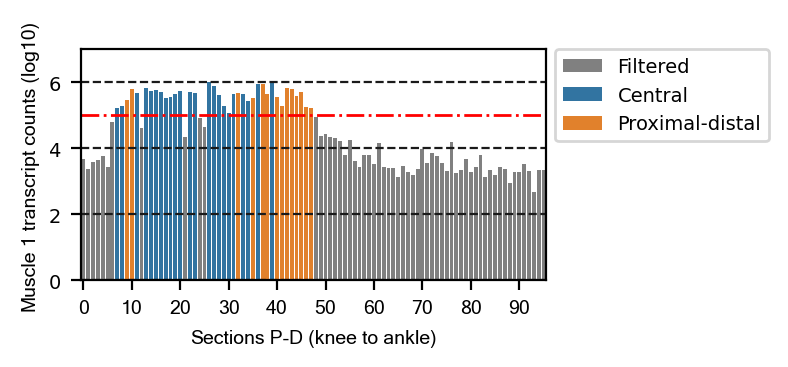

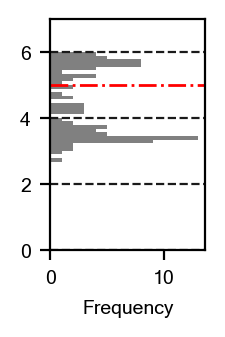

In [33]:
plt.rcParams.update(plt.rcParamsDefault)
# Define bar properties
bar_heights = list(data['Muscle_1']['log10'])
sections = np.arange(1,97)
labels = list(data['Muscle_1']['leiden'])

# Build dataframe
df = pd.DataFrame({'Transcript counts': bar_heights,
                   'Section': sections,
                   'Leiden cluster': labels})

palette = {
    'Central': 'tab:blue',
    'Proximal-distal': 'tab:orange',
    'Filtered': 'grey'
}

plt.figure(figsize=(3, 1.5))
sns.barplot(x="Section", hue="Leiden cluster", y="Transcript counts", data=df, palette=palette, dodge = False)

plt.xlabel('Sections P-D (knee to ankle)', fontsize=7, fontname="Microsoft Sans Serif")
plt.ylabel('Muscle 1 transcript counts (log10)', fontsize=7, fontname="Microsoft Sans Serif")
plt.yticks(fontsize=7)
plt.ylim([0, 7])
#select everyother 10 labels from the list of column names
plt.xticks(ticks=np.arange(0, 96, 10), labels=[str(i) for i in range(0,96,10)], rotation='horizontal', fontsize=7, fontname="Microsoft Sans Serif")
plt.grid(which='major', axis='y', linestyle='--', c='k')
plt.axhline(y=5, color='red', linestyle='-.', linewidth = 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=7)

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 7
plt.savefig('coverage_M1_cluters.svg', format = 'svg', dpi=300, bbox_inches='tight')  
plt.show()
plt.close()

#plot the frequency form the selection
df['Transcript counts'].plot(kind='hist', legend=False, figsize=(1, 1.5), bins=30, color='grey', orientation='horizontal');
plt.axhline(y=5, color='red', linestyle='-.', linewidth = 1)
plt.ylim([0, 7])
plt.xlabel('Frequency', fontsize=7, fontname="Microsoft Sans Serif")

plt.xticks(fontsize=7, fontname="Microsoft Sans Serif")
plt.yticks(fontsize=7, fontname="Microsoft Sans Serif")
plt.grid(which='major', axis='y', linestyle='--', c='k')
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('Trans-counts_freq_M1_clusters.svg', format = 'svg', dpi=300, bbox_inches='tight')   
plt.show()
plt.close()

In [34]:
adata_2=adata[adata.obs["Sample"] == "Muscle_2"]
data_2=pd.DataFrame(adata_2.obs)
data_2=data_2.set_index('Section')

list_cluster=[]
list_color=[]

for index in data['Muscle_2'].index:
    if data['Muscle_2'].loc[index]['Filter'] == 'No':
        list_cluster.append('Filtered')
        list_color.append('grey')
    else:
        list_cluster.append(data_2.loc[data['Muscle_2'].loc[index]['Filter']]['leiden'])
        list_color.append(data_2.loc[data['Muscle_2'].loc[index]['Filter']]['color'])
data['Muscle_2']['leiden']=list_cluster
data['Muscle_2']['color']=list_color

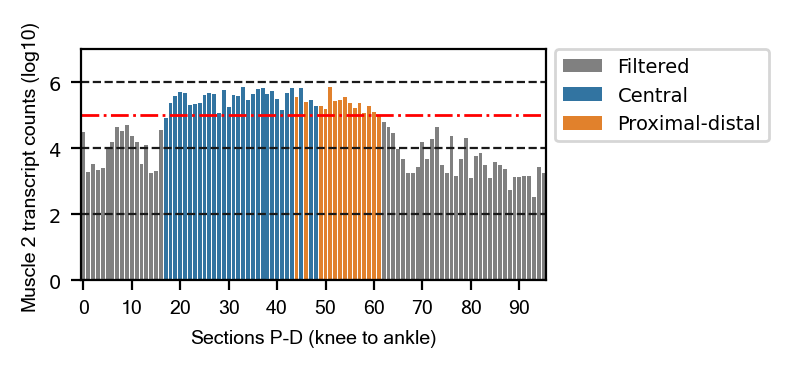

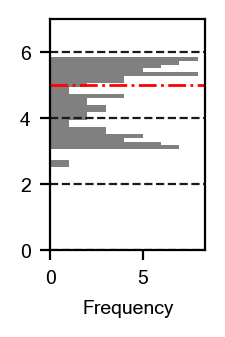

In [35]:
plt.rcParams.update(plt.rcParamsDefault)
# Define bar properties
bar_heights = list(data['Muscle_2']['log10'])
sections = np.arange(1,97)
labels = list(data['Muscle_2']['leiden'])

# Build dataframe
df = pd.DataFrame({'Transcript counts': bar_heights,
                   'Section': sections,
                   'Leiden cluster': labels})

palette = {
    'Central': 'tab:blue',
    'Proximal-distal': 'tab:orange',
    'Filtered': 'grey'
}

plt.figure(figsize=(3, 1.5))
sns.barplot(x="Section", hue="Leiden cluster", y="Transcript counts", data=df, palette=palette, dodge = False)

plt.xlabel('Sections P-D (knee to ankle)', fontsize=7, fontname="Microsoft Sans Serif")
plt.ylabel('Muscle 2 transcript counts (log10)', fontsize=7, fontname="Microsoft Sans Serif")
plt.yticks(fontsize=7)
plt.ylim([0, 7])
#select everyother 10 labels from the list of column names
plt.xticks(ticks=np.arange(0, 96, 10), labels=[str(i) for i in range(0,96,10)], rotation='horizontal', fontsize=7, fontname="Microsoft Sans Serif")
plt.grid(which='major', axis='y', linestyle='--', c='k')
plt.axhline(y=5, color='red', linestyle='-.', linewidth = 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=7)

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 7
plt.savefig('coverage_M2_cluters.svg', format = 'svg', dpi=300, bbox_inches='tight')  
plt.show()
plt.close()

#plot the frequency form the selection
df['Transcript counts'].plot(kind='hist', legend=False, figsize=(1, 1.5), bins=30, color='grey', orientation='horizontal');
plt.axhline(y=5, color='red', linestyle='-.', linewidth = 1)
plt.ylim([0, 7])
plt.xlabel('Frequency', fontsize=7, fontname="Microsoft Sans Serif")

plt.xticks(fontsize=7, fontname="Microsoft Sans Serif")
plt.yticks(fontsize=7, fontname="Microsoft Sans Serif")
plt.grid(which='major', axis='y', linestyle='--', c='k')
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('Trans-counts_freq_M2_clusters.svg', format = 'svg', dpi=300, bbox_inches='tight')   
plt.show()
plt.close()

In [36]:
adata_3=adata[adata.obs["Sample"] == "Muscle_3"]
data_3=pd.DataFrame(adata_3.obs)
data_3=data_3.set_index('Section')

list_cluster=[]
list_color=[]

for index in data['Muscle_3'].index:
    if data['Muscle_3'].loc[index]['Filter'] == 'No':
        list_cluster.append('Filtered')
        list_color.append('grey')
    else:
        list_cluster.append(data_3.loc[data['Muscle_3'].loc[index]['Filter']]['leiden'])
        list_color.append(data_3.loc[data['Muscle_3'].loc[index]['Filter']]['color'])
data['Muscle_3']['leiden']=list_cluster
data['Muscle_3']['color']=list_color

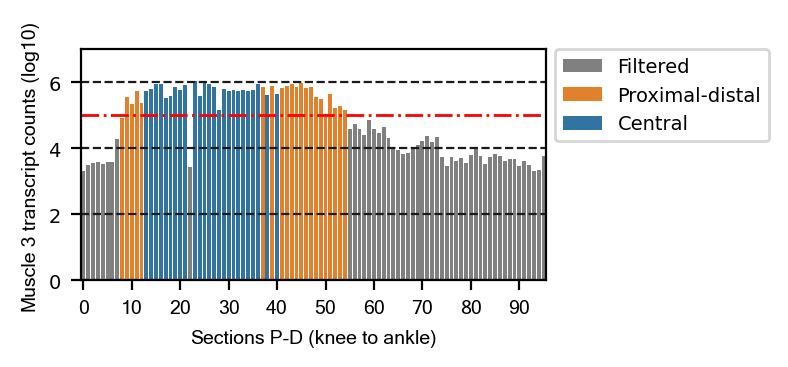

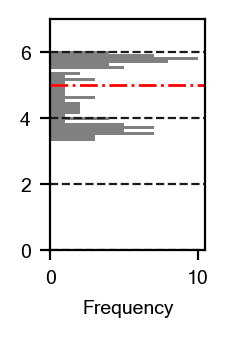

In [37]:
plt.rcParams.update(plt.rcParamsDefault)
# Define bar properties
bar_heights = list(data['Muscle_3']['log10'])
sections = np.arange(1,97)
labels = list(data['Muscle_3']['leiden'])

# Build dataframe
df = pd.DataFrame({'Transcript counts': bar_heights,
                   'Section': sections,
                   'Leiden cluster': labels})

palette = {
    'Central': 'tab:blue',
    'Proximal-distal': 'tab:orange',
    'Filtered': 'grey'
}

plt.figure(figsize=(3, 1.5))
sns.barplot(x="Section", hue="Leiden cluster", y="Transcript counts", data=df, palette=palette, dodge = False)

plt.xlabel('Sections P-D (knee to ankle)', fontsize=7, fontname="Microsoft Sans Serif")
plt.ylabel('Muscle 3 transcript counts (log10)', fontsize=7, fontname="Microsoft Sans Serif")
plt.yticks(fontsize=7)
plt.ylim([0, 7])
#select everyother 10 labels from the list of column names
plt.xticks(ticks=np.arange(0, 96, 10), labels=[str(i) for i in range(0,96,10)], rotation='horizontal', fontsize=7, fontname="Microsoft Sans Serif")
plt.grid(which='major', axis='y', linestyle='--', c='k')
plt.axhline(y=5, color='red', linestyle='-.', linewidth = 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=7)

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 7
plt.savefig('coverage_M3_cluters.svg', format = 'svg', dpi=300, bbox_inches='tight')  
plt.show()
plt.close()

#plot the frequency form the selection
df['Transcript counts'].plot(kind='hist', legend=False, figsize=(1, 1.5), bins=30, color='grey', orientation='horizontal');
plt.axhline(y=5, color='red', linestyle='-.', linewidth = 1)
plt.ylim([0, 7])
plt.xlabel('Frequency', fontsize=7, fontname="Microsoft Sans Serif")

plt.xticks(fontsize=7, fontname="Microsoft Sans Serif")
plt.yticks(fontsize=7, fontname="Microsoft Sans Serif")
plt.grid(which='major', axis='y', linestyle='--', c='k')
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('Trans-counts_freq_M3_clusters.svg', format = 'svg', dpi=300, bbox_inches='tight')   
plt.show()
plt.close()

In [38]:
adata_4=adata[adata.obs["Sample"] == "Muscle_4"]
data_4=pd.DataFrame(adata_4.obs)
data_4=data_4.set_index('Section')

list_cluster=[]
list_color=[]

for index in data['Muscle_4'].index:
    if data['Muscle_4'].loc[index]['Filter'] == 'No':
        list_cluster.append('Filtered')
        list_color.append('grey')
    else:
        list_cluster.append(data_4.loc[data['Muscle_4'].loc[index]['Filter']]['leiden'])
        list_color.append(data_4.loc[data['Muscle_4'].loc[index]['Filter']]['color'])
data['Muscle_4']['leiden']=list_cluster
data['Muscle_4']['color']=list_color

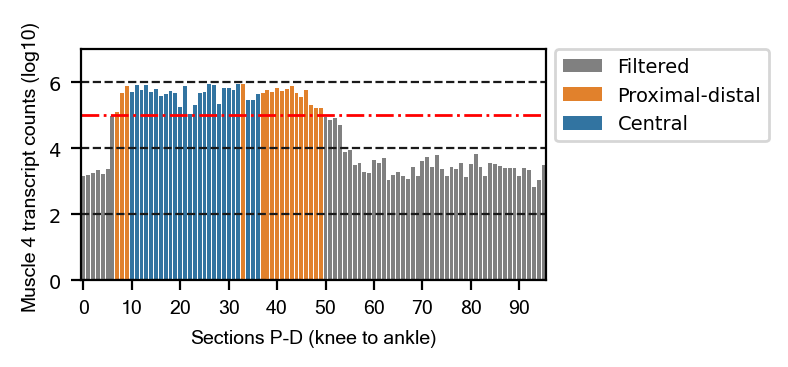

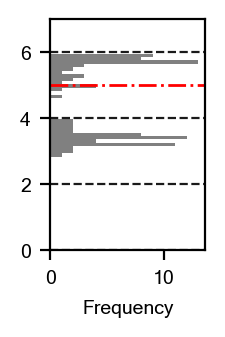

In [39]:
plt.rcParams.update(plt.rcParamsDefault)
# Define bar properties
bar_heights = list(data['Muscle_4']['log10'])
sections = np.arange(1,97)
labels = list(data['Muscle_4']['leiden'])

# Build dataframe
df = pd.DataFrame({'Transcript counts': bar_heights,
                   'Section': sections,
                   'Leiden cluster': labels})

palette = {
    'Central': 'tab:blue',
    'Proximal-distal': 'tab:orange',
    'Filtered': 'grey'
}

plt.figure(figsize=(3, 1.5))
sns.barplot(x="Section", hue="Leiden cluster", y="Transcript counts", data=df, palette=palette, dodge = False)

plt.xlabel('Sections P-D (knee to ankle)', fontsize=7, fontname="Microsoft Sans Serif")
plt.ylabel('Muscle 4 transcript counts (log10)', fontsize=7, fontname="Microsoft Sans Serif")
plt.yticks(fontsize=7)
plt.ylim([0, 7])
#select everyother 10 labels from the list of column names
plt.xticks(ticks=np.arange(0, 96, 10), labels=[str(i) for i in range(0,96,10)], rotation='horizontal', fontsize=7, fontname="Microsoft Sans Serif")
plt.grid(which='major', axis='y', linestyle='--', c='k')
plt.axhline(y=5, color='red', linestyle='-.', linewidth = 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=7)

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 7
plt.savefig('coverage_M4_cluters.svg', format = 'svg', dpi=300, bbox_inches='tight')  
plt.show()
plt.close()

#plot the frequency form the selection
df['Transcript counts'].plot(kind='hist', legend=False, figsize=(1, 1.5), bins=30, color='grey', orientation='horizontal');
plt.axhline(y=5, color='red', linestyle='-.', linewidth = 1)
plt.ylim([0, 7])
plt.xlabel('Frequency', fontsize=7, fontname="Microsoft Sans Serif")

plt.xticks(fontsize=7, fontname="Microsoft Sans Serif")
plt.yticks(fontsize=7, fontname="Microsoft Sans Serif")
plt.grid(which='major', axis='y', linestyle='--', c='k')
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('Trans-counts_freq_M4_clusters.svg', format = 'svg', dpi=300, bbox_inches='tight')   
plt.show()
plt.close()

In [40]:
data['Muscle_1'].to_excel('data_filter_Muscle1_clusters.xlsx') 
data['Muscle_2'].to_excel('data_filter_Muscle2_clusters.xlsx') 
data['Muscle_3'].to_excel('data_filter_Muscle3_clusters.xlsx') 
data['Muscle_4'].to_excel('data_filter_Muscle4_clusters.xlsx') 

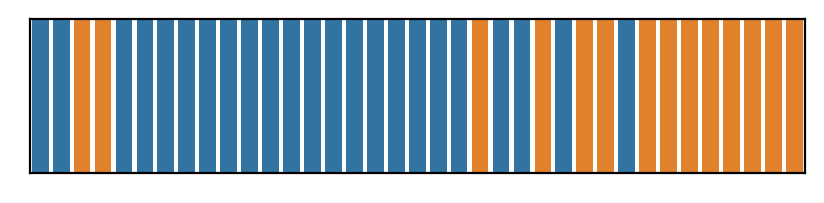

In [41]:
adata_1=adata[adata.obs["Sample"] == "Muscle_1"]
data_1=pd.DataFrame(adata_1.obs)
data_1['Transcript counts'] = [10]*len(adata_1.obs)
# Define bar properties
bar_heights = list(np.log10(data_1['Transcript counts']))
sections = [str(i) for i in data_1['Section']]
labels = list(data_1['leiden'])

# Build dataframe
df = pd.DataFrame({'Transcript counts': bar_heights,
                   'Section': sections,
                   'Leiden cluster': labels})


palette = {
    'Central': 'tab:blue',
    'Proximal-distal': 'tab:orange',
}

plt.figure(figsize=(5, 1))
sns.barplot(data=df, x="Section", hue="Leiden cluster", y="Transcript counts", palette=palette, order=df['Section'], dodge = False)
plt.xlabel(None)
plt.ylabel(None)
plt.ylim([0, 1])
plt.xticks([]),plt.yticks([])
plt.legend('',frameon=False)
plt.savefig('M1_clusters.svg', format = 'svg', dpi=300, bbox_inches='tight')  
plt.show()

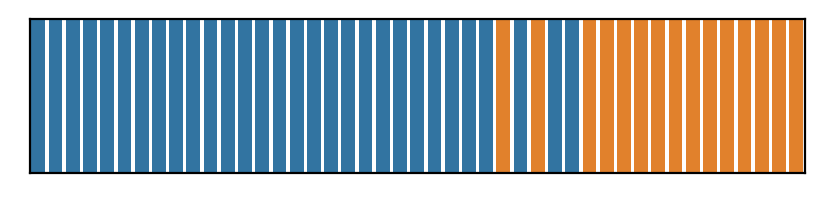

In [42]:
adata_2=adata[adata.obs["Sample"] == "Muscle_2"]
data_2=pd.DataFrame(adata_2.obs)
data_2['Transcript counts'] = [10]*len(adata_2.obs)
# Define bar properties
bar_heights = list(np.log10(data_2['Transcript counts']))
sections = [str(i) for i in data_2['Section']]
labels = list(data_2['leiden'])

# Build dataframe
df = pd.DataFrame({'Transcript counts': bar_heights,
                   'Section': sections,
                   'Leiden cluster': labels})


palette = {
    'Central': 'tab:blue',
    'Proximal-distal': 'tab:orange',
}

plt.figure(figsize=(5, 1))
sns.barplot(data=df, x="Section", hue="Leiden cluster", y="Transcript counts", palette=palette, order=df['Section'], dodge = False)
plt.xlabel(None)
plt.ylabel(None)
plt.ylim([0, 1])
plt.xticks([]),plt.yticks([])
plt.legend('',frameon=False)
plt.savefig('M2_clusters.svg', format = 'svg', dpi=300, bbox_inches='tight') 
plt.show()

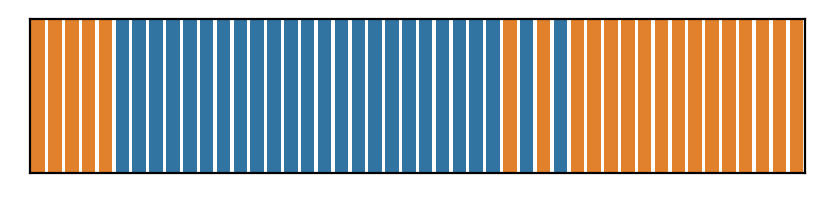

In [43]:
adata_3=adata[adata.obs["Sample"] == "Muscle_3"]
data_3=pd.DataFrame(adata_3.obs)
data_3['Transcript counts'] = [10]*len(adata_3.obs)
# Define bar properties
bar_heights = list(np.log10(data_3['Transcript counts']))
sections = [str(i) for i in data_3['Section']]
labels = list(data_3['leiden'])

# Build dataframe
df = pd.DataFrame({'Transcript counts': bar_heights,
                   'Section': sections,
                   'Leiden cluster': labels})


palette = {
    'Central': 'tab:blue',
    'Proximal-distal': 'tab:orange',
}

plt.figure(figsize=(5, 1))
sns.barplot(data=df, x="Section", hue="Leiden cluster", y="Transcript counts", palette=palette, order=df['Section'], dodge = False)
plt.xlabel(None)
plt.ylabel(None)
plt.ylim([0, 1])
plt.xticks([]),plt.yticks([])
plt.legend('',frameon=False)
plt.savefig('M3_clusters.svg', format = 'svg', dpi=300, bbox_inches='tight') 
plt.show()

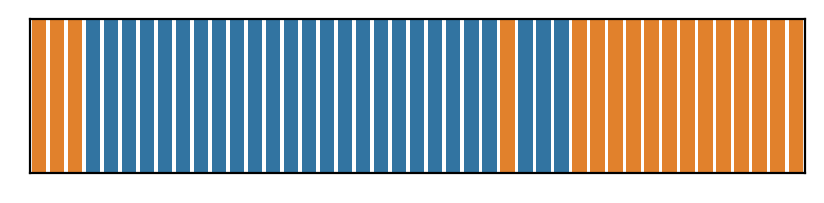

In [44]:
adata_4=adata[adata.obs["Sample"] == "Muscle_4"]
data_4=pd.DataFrame(adata_4.obs)
data_4['Transcript counts'] = [10]*len(adata_4.obs)
# Define bar properties
bar_heights = list(np.log10(data_4['Transcript counts']))
sections = [str(i) for i in data_4['Section']]
labels = list(data_4['leiden'])

# Build dataframe
df = pd.DataFrame({'Transcript counts': bar_heights,
                   'Section': sections,
                   'Leiden cluster': labels})


palette = {
    'Central': 'tab:blue',
    'Proximal-distal': 'tab:orange',
}

plt.figure(figsize=(5, 1))
sns.barplot(data=df, x="Section", hue="Leiden cluster", y="Transcript counts", palette=palette, order=df['Section'], dodge = False)
plt.xlabel(None)
plt.ylabel(None)
plt.ylim([0, 1])
plt.xticks([]),plt.yticks([])
plt.legend('',frameon=False)
plt.savefig('M4_clusters.svg', format = 'svg', dpi=300, bbox_inches='tight') 
plt.show()

### DEG analysis

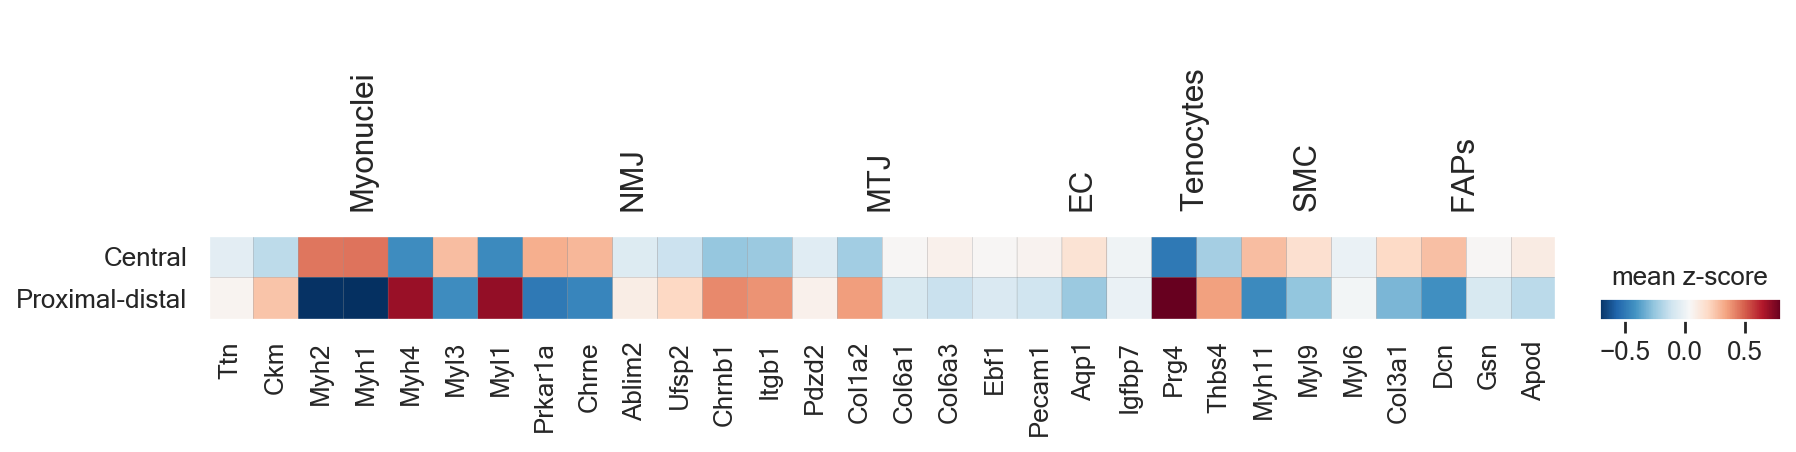

In [27]:
#Compare data to snRNAseq marker genes for MTJ, NMJ, myonuclei, FAPs, Endothelial, etc.
marker_genes_dict = {
    'Myonuclei': ['Ttn', 'Ckm', 'Myh2', 'Myh1', 'Myh4', 'Myl3', 'Myl1'],
    'NMJ': ['Prkar1a', 'Chrne', 'Ablim2', 'Ufsp2', 'Chrnb1'],
    'MTJ': ['Itgb1', 'Pdzd2', 'Col1a2', 'Col6a1', 'Col6a3', 'Ebf1'],
    'EC': ['Pecam1', 'Aqp1', 'Igfbp7'],
    'Tenocytes': ['Prg4', 'Thbs4'],
    'SMC': ['Myh11', 'Myl9', 'Myl6'],
    'FAPs': ['Col3a1', 'Dcn', 'Gsn', 'Apod']
}

#Compare data to snRNAseq marker genes for MTJ, NMJ, myonuclei, FAPs, Endothelial, etc.
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.rcParams["font.size"] = 14
sc.pl.matrixplot(adata, marker_genes_dict, groupby='leiden',  cmap='RdBu_r', gene_symbols='gene_name', colorbar_title='mean z-score', show=False);
plt.savefig('cluster-composition.svg', format = 'svg', dpi=300, bbox_inches='tight')   
plt.show()
plt.close()




In [28]:
gene_ids = adata.var.index.values 
clusters = adata.obs['leiden'].cat.categories 
obs = adata[:,gene_ids].X.toarray() 
obs = pd.DataFrame(obs,columns=gene_ids,index=adata.obs['leiden'])
marker_genes = ['Ttn', 'Ckm', 'Myh2', 'Myh1', 'Myh4', 'Myl3', 'Myl1','Prkar1a', 'Chrne', 'Ablim2', 'Ufsp2', 'Chrnb1','Itgb1', 'Pdzd2', 'Col1a2', 'Col6a1', 'Col6a3', 'Ebf1', 'Pecam1', 'Aqp1', 'Igfbp7', 'Prg4', 'Thbs4', 'Myh11', 'Myl9', 'Myl6','Col3a1', 'Dcn', 'Gsn', 'Apod']
out = [id for id in obs.columns if any(g in id for g in marker_genes)]
average_obs = obs.groupby(level=0).mean() 
average_obs=average_obs[out]
average_obs.T.to_excel("cluster-composition_average.xlsx") 
average_obs

,ENSMUSG00000001119_Col6a1_ProteinCoding,ENSMUSG00000004655_Aqp1_ProteinCoding,ENSMUSG00000006014_Prg4_ProteinCoding,ENSMUSG00000014609_Chrne_ProteinCoding,ENSMUSG00000018830_Myh11_ProteinCoding,ENSMUSG00000019929_Dcn_ProteinCoding,ENSMUSG00000020612_Prkar1a_ProteinCoding,ENSMUSG00000020717_Pecam1_ProteinCoding,ENSMUSG00000021622_Ckmt2_ProteinCoding,ENSMUSG00000021702_Thbs4_ProteinCoding,...,ENSMUSG00000048126_Col6a3_ProteinCoding,ENSMUSG00000051747_Ttn_ProteinCoding,ENSMUSG00000056328_Myh1_ProteinCoding,ENSMUSG00000057003_Myh4_ProteinCoding,ENSMUSG00000057098_Ebf1_ProteinCoding,ENSMUSG00000059741_Myl3_ProteinCoding,ENSMUSG00000061816_Myl1_ProteinCoding,ENSMUSG00000062352_Itgb1bp1_ProteinCoding,ENSMUSG00000067818_Myl9_ProteinCoding,ENSMUSG00000090841_Myl6_ProteinCoding
leiden,,,,,,,,,,,,,,,,,,,,,
Central,0.050387,0.151035,-0.501749,0.290146,0.277008,0.265560,0.314005,0.067962,0.561257,-0.219426,...,0.081545,-0.039146,0.450787,-0.436175,0.046494,0.275218,-0.443171,-0.252836,0.163502,-0.011935
Proximal-distal,-0.080162,-0.240283,0.798237,-0.461596,-0.440694,-0.422482,-0.499553,-0.108121,-0.892910,0.349087,...,-0.129731,0.062278,-0.717161,0.693915,-0.073968,-0.437847,0.705044,0.402239,-0.260116,0.018987


/Users/claramartinezmir/venv/base-env-DMD/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/claramartinezmir/venv/base-env-DMD/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


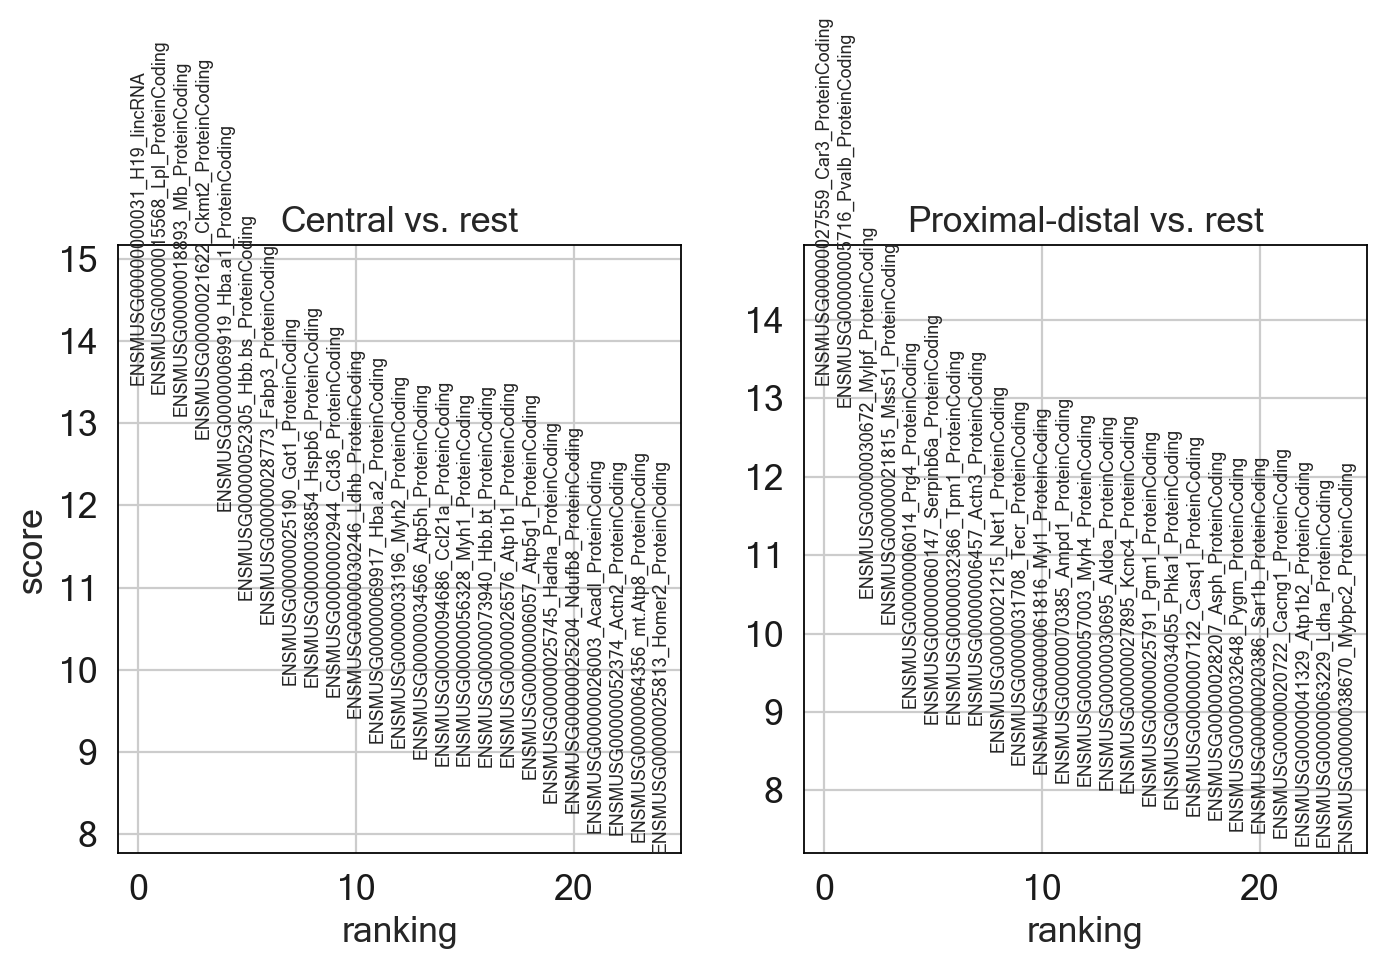

In [29]:
##Finding marker genes
sc.set_figure_params(fontsize=16, figsize=(5,5), color_map='Spectral_r')
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)


In [48]:
adata.uns['rank_genes_groups']

{'params': {'groupby': 'leiden',
  'reference': 'rest',
  'method': 't-test',
  'use_raw': False,
  'layer': None,
  'corr_method': 'benjamini-hochberg'},
 'names': rec.array([('ENSMUSG00000015568_Lpl_ProteinCoding', 'ENSMUSG00000027559_Car3_ProteinCoding'),
            ('ENSMUSG00000018893_Mb_ProteinCoding', 'ENSMUSG00000005716_Pvalb_ProteinCoding'),
            ('ENSMUSG00000000031_H19_lincRNA', 'ENSMUSG00000030672_Mylpf_ProteinCoding'),
            ...,
            ('ENSMUSG00000030672_Mylpf_ProteinCoding', 'ENSMUSG00000000031_H19_lincRNA'),
            ('ENSMUSG00000005716_Pvalb_ProteinCoding', 'ENSMUSG00000018893_Mb_ProteinCoding'),
            ('ENSMUSG00000027559_Car3_ProteinCoding', 'ENSMUSG00000015568_Lpl_ProteinCoding')],
           dtype=[('Central', 'O'), ('Proximal-distal', 'O')]),
 'scores': rec.array([( 12.591125,  12.429864), ( 11.765312,  11.763547),
            ( 11.51426 ,  11.226074), ..., (-11.226074, -11.51426 ),
            (-11.763547, -11.765312), (-12.429864, 

In [30]:
adata.uns['rank_genes_groups']

{'params': {'groupby': 'leiden',
  'reference': 'rest',
  'method': 't-test',
  'use_raw': False,
  'layer': None,
  'corr_method': 'benjamini-hochberg'},
 'names': rec.array([('ENSMUSG00000000031_H19_lincRNA', 'ENSMUSG00000027559_Car3_ProteinCoding'),
            ('ENSMUSG00000015568_Lpl_ProteinCoding', 'ENSMUSG00000005716_Pvalb_ProteinCoding'),
            ('ENSMUSG00000018893_Mb_ProteinCoding', 'ENSMUSG00000030672_Mylpf_ProteinCoding'),
            ...,
            ('ENSMUSG00000030672_Mylpf_ProteinCoding', 'ENSMUSG00000018893_Mb_ProteinCoding'),
            ('ENSMUSG00000005716_Pvalb_ProteinCoding', 'ENSMUSG00000015568_Lpl_ProteinCoding'),
            ('ENSMUSG00000027559_Car3_ProteinCoding', 'ENSMUSG00000000031_H19_lincRNA')],
           dtype=[('Central', 'O'), ('Proximal-distal', 'O')]),
 'scores': rec.array([( 13.461635,  13.164312), ( 13.354594,  12.885501),
            ( 13.085234,  10.452997), ..., (-10.452997, -13.085234),
            (-12.885501, -13.354594), (-13.164312, 

In [49]:
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
deg_data_noAdj = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'scores', 'pvals']})

deg_data = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'scores','pvals_adj']})
deg_data

,Central_n,Central_s,Central_p,Proximal-distal_n,Proximal-distal_s,Proximal-distal_p
0,ENSMUSG00000015568_Lpl_ProteinCoding,12.591125,9.979596e-21,ENSMUSG00000027559_Car3_ProteinCoding,12.429864,2.346228e-20
1,ENSMUSG00000018893_Mb_ProteinCoding,11.765312,6.231995e-19,ENSMUSG00000005716_Pvalb_ProteinCoding,11.763547,6.210816e-19
2,ENSMUSG00000000031_H19_lincRNA,11.514260,1.837336e-19,ENSMUSG00000030672_Mylpf_ProteinCoding,11.226074,1.116402e-18
3,ENSMUSG00000021622_Ckmt2_ProteinCoding,11.321798,2.644431e-18,ENSMUSG00000021815_Mss51_ProteinCoding,10.045104,5.221850e-14
4,ENSMUSG00000069919_Hba.a1_ProteinCoding,10.452645,3.291169e-17,ENSMUSG00000031708_Tecr_ProteinCoding,8.985861,5.736622e-13
...,...,...,...,...,...,...
4109,ENSMUSG00000031708_Tecr_ProteinCoding,-8.985861,5.736622e-13,ENSMUSG00000069919_Hba.a1_ProteinCoding,-10.452645,3.291169e-17
4110,ENSMUSG00000021815_Mss51_ProteinCoding,-10.045104,5.221850e-14,ENSMUSG00000021622_Ckmt2_ProteinCoding,-11.321798,2.644431e-18
4111,ENSMUSG00000030672_Mylpf_ProteinCoding,-11.226074,1.116402e-18,ENSMUSG00000000031_H19_lincRNA,-11.514260,1.837336e-19
4112,ENSMUSG00000005716_Pvalb_ProteinCoding,-11.763547,6.210816e-19,ENSMUSG00000018893_Mb_ProteinCoding,-11.765312,6.231995e-19


In [50]:
#separete dataframes and add mean zscore
#add the mean z-score value for each gene from each cluster
res = pd.DataFrame(columns=adata.var_names, index=adata.obs['leiden'].cat.categories)                                                                                                 

for clust in adata.obs.leiden.cat.categories: 
    res.loc[clust] = adata[adata.obs['leiden'].isin([clust]),:].X.mean(0)
res=res.T

#add the z-score diff and pvalues
res['Mean z-score difference'] = res['Central'].sub(res['Proximal-distal'])

data_pvalue=deg_data.set_index('Central_n').drop(['Central_s','Proximal-distal_n', 'Proximal-distal_p', 'Proximal-distal_s'], axis=1)
data_pvalue=data_pvalue.rename(columns={"Central_p": "Central_adj_p"})
proximaldist_score=deg_data.set_index('Proximal-distal_n').drop(['Central_n', 'Central_s', 'Central_p', 'Proximal-distal_p'], axis=1)
data_noAdjpvalue=deg_data_noAdj.set_index('Central_n').drop(['Proximal-distal_n', 'Proximal-distal_p', 'Proximal-distal_s'], axis=1)

data_deg_table=pd.concat([res,proximaldist_score], axis=1)
data_deg_table=pd.concat([data_deg_table,data_noAdjpvalue], axis=1)
data_deg_table=pd.concat([data_deg_table,data_pvalue], axis=1)
data_deg_table=data_deg_table.drop(['Proximal-distal','Central'], axis=1)
data_deg_table=data_deg_table.rename(columns={"Central_p": "p_value", "Central_adj_p": "adj_p_value"})
data_deg_table.to_excel("deg_data_pvalues.xlsx") 
data_deg_table

,Mean z-score difference,Proximal-distal_s,Central_s,p_value,adj_p_value
ENSMUSG00000000031_H19_lincRNA,1.331939,-11.514260,11.514260,1.339818e-22,1.837336e-19
ENSMUSG00000000056_Narf_ProteinCoding,-0.16508,0.984629,-0.984629,3.269434e-01,5.723596e-01
ENSMUSG00000000078_Klf6_ProteinCoding,0.199771,-1.263283,1.263283,2.086327e-01,4.497115e-01
ENSMUSG00000000085_Scmh1_ProteinCoding,-0.013495,0.084829,-0.084829,9.325214e-01,9.715272e-01
ENSMUSG00000000088_Cox5a_ProteinCoding,0.833008,-5.681613,5.681613,8.115821e-08,3.063164e-06
...,...,...,...,...,...
ENSMUSG00000113902_Ndufb1.ps_ProteinCoding,0.743823,-5.396659,5.396659,2.317409e-07,7.944851e-06
ENSMUSG00000115987_Vps28_ProteinCoding,0.011708,-0.073377,0.073377,9.416144e-01,9.747865e-01
ENSMUSG00000116590_AC154200.1_lincRNA,-0.112502,0.672093,-0.672093,5.029011e-01,7.293044e-01
ENSMUSG00000117924_Tmem223_ProteinCoding,-0.12155,0.773741,-0.773741,4.403740e-01,6.787930e-01


In [51]:
res

,Central,Proximal-distal,Mean z-score difference
gene_id,,,
ENSMUSG00000000031_H19_lincRNA,0.521871,-0.810068,1.331939
ENSMUSG00000000056_Narf_ProteinCoding,-0.06468,0.100399,-0.16508
ENSMUSG00000000078_Klf6_ProteinCoding,0.078273,-0.121498,0.199771
ENSMUSG00000000085_Scmh1_ProteinCoding,-0.005288,0.008208,-0.013495
ENSMUSG00000000088_Cox5a_ProteinCoding,0.326383,-0.506625,0.833008
...,...,...,...
ENSMUSG00000113902_Ndufb1.ps_ProteinCoding,0.291439,-0.452384,0.743823
ENSMUSG00000115987_Vps28_ProteinCoding,0.004587,-0.007121,0.011708
ENSMUSG00000116590_AC154200.1_lincRNA,-0.04408,0.068422,-0.112502


In [52]:
#select DEG based on p value and man z-score diff
deg_list_c1_up = []
deg_list_c1_down = []
for index in deg_data.index:
    #check that the pvale is smaller than 0.05
    if deg_data.iloc[index][2]<=0.05:
        #check that the zscore difference is bigger than 1.0 between Central and Proximal-Distal. 
        #Find the gene name corresponding to every index for each region 
            #deg_data.iloc[index][0] --> Central
            #deg_data.iloc[index][2] --> Proximal-Distal
            #deg_data.iloc[index][4] --> Central_2
            #deg_data.iloc[index][6] --> transition
        if (res.loc[deg_data.iloc[index][0]]['Central']-res.loc[deg_data.iloc[index][0]]['Proximal-distal'])>=0.4:
            deg_list_c1_up.append(deg_data.iloc[index][0])
print(len(deg_list_c1_up))


deg_list_c2_up = []
deg_list_c2_down = []
for index in deg_data.index:
    if deg_data.iloc[index][5]<=0.05:
        if (res.loc[deg_data.iloc[index][3]]['Proximal-distal']-res.loc[deg_data.iloc[index][3]]['Central'])>=0.4:
            deg_list_c2_up.append(deg_data.iloc[index][3])
print(len(deg_list_c2_up))



deg_list=list(dict.fromkeys(deg_list_c1_up+deg_list_c2_up))
print(len(deg_list))

data_deg={}
for key in data_genes_filtered_normal:
    data_deg[key]=data_genes_filtered_normal[key].loc[deg_list]
data_deg

398
288
686


{'Muscle_1':                                                   001          002  \
 new_gene                                                             
 ENSMUSG00000015568_Lpl_ProteinCoding       102.106895    95.015603   
 ENSMUSG00000018893_Mb_ProteinCoding       1518.684082  1361.680333   
 ENSMUSG00000000031_H19_lincRNA             525.703164   648.449576   
 ENSMUSG00000021622_Ckmt2_ProteinCoding     139.201480   190.853658   
 ENSMUSG00000069919_Hba.a1_ProteinCoding    434.455107   204.612781   
 ...                                               ...          ...   
 ENSMUSG00000024548_Setbp1_ProteinCoding      2.824165     2.703446   
 ENSMUSG00000078941_Ak6_ProteinCoding         8.474564     8.112320   
 ENSMUSG00000027637_Rab5if_ProteinCoding     11.300799    21.646076   
 ENSMUSG00000028964_Park7_ProteinCoding      48.104837    29.774278   
 ENSMUSG00000079278_Tmem233_ProteinCoding     8.474564    27.064214   
 
                                                   003         

In [53]:
#calculate the szcores
data_deg_zscores = zscores(data_deg)
data_deg_zscores

{'Muscle_1':                                                001       002       003  \
 new_gene                                                                 
 ENSMUSG00000015568_Lpl_ProteinCoding     -0.948932 -1.150101  0.563149   
 ENSMUSG00000018893_Mb_ProteinCoding       0.228222 -0.504750  0.121778   
 ENSMUSG00000000031_H19_lincRNA           -1.036785 -0.373270  0.263263   
 ENSMUSG00000021622_Ckmt2_ProteinCoding   -1.345129  0.146068 -0.024021   
 ENSMUSG00000069919_Hba.a1_ProteinCoding  -0.541062 -1.453766 -1.150003   
 ...                                            ...       ...       ...   
 ENSMUSG00000024548_Setbp1_ProteinCoding  -1.243572 -1.284722  1.068093   
 ENSMUSG00000078941_Ak6_ProteinCoding      0.275729  0.139859  2.503464   
 ENSMUSG00000027637_Rab5if_ProteinCoding  -1.726595  0.437611 -0.068735   
 ENSMUSG00000028964_Park7_ProteinCoding    1.053491 -0.855675  2.068159   
 ENSMUSG00000079278_Tmem233_ProteinCoding -2.397377  0.942048 -0.466063   
 
           

In [54]:
#Now let's normalize the Z score to scaled Z score (-1 to 1)
#Calculate scaled zscors
data_deg_scaled_zscores = scaledZscores(data_deg_zscores)
data_deg_scaled_zscores

{'Muscle_1':                                                001       002       003  \
 new_gene                                                                 
 ENSMUSG00000015568_Lpl_ProteinCoding     -0.375701 -0.472522  0.352051   
 ENSMUSG00000018893_Mb_ProteinCoding       0.306266 -0.032696  0.257041   
 ENSMUSG00000000031_H19_lincRNA           -0.553308 -0.219498  0.100738   
 ENSMUSG00000021622_Ckmt2_ProteinCoding   -0.582340  0.218478  0.127135   
 ENSMUSG00000069919_Hba.a1_ProteinCoding  -0.486367 -0.959228 -0.801852   
 ...                                            ...       ...       ...   
 ENSMUSG00000024548_Setbp1_ProteinCoding  -0.613204 -0.629738  0.315601   
 ENSMUSG00000078941_Ak6_ProteinCoding     -0.077452 -0.143166  1.000000   
 ENSMUSG00000027637_Rab5if_ProteinCoding  -0.605114  0.338612  0.117814   
 ENSMUSG00000028964_Park7_ProteinCoding    0.422525 -0.396721  0.857931   
 ENSMUSG00000079278_Tmem233_ProteinCoding -1.000000  0.509458 -0.127024   
 
           

In [55]:
#save data 
saveCSV(data_deg, label = 'data_deg')
saveCSV(data_deg_zscores, label = 'data_deg_zscores')
saveCSV(data_deg_scaled_zscores, label = 'data_deg_scaled_zscores')
for key in data_deg_scaled_zscores:
    data_deg_scaled_zscores[key].to_excel('deg_'+key+'.xlsx')

Files saved
Files saved
Files saved


In [56]:
adata

AnnData object with n_obs × n_vars = 171 × 4114
    obs: 'Section', 'Sample', 'Region', 'leiden', 'Transcript counts', 'PC1', 'PC2', 'color'
    var: 'gene_id', 'gene_name'
    uns: 'pca', 'Sample_colors', 'Region_colors', 'Section_colors', 'neighbors', 'leiden', 'leiden_colors', 'rank_genes_groups'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [58]:
adata_plot=adata[adata.obs["leiden"] == "Central"]
ann=pd.DataFrame(adata_plot.obs)
df_c=adata[adata.obs["leiden"] == "Central"].to_df().T
df_a=adata[adata.obs["leiden"] == "Proximal-distal"].to_df().T
df_plot=pd.concat([df_c, df_a], axis=1).loc[data_deg_scaled_zscores['Muscle_1'].index]
df_plot

,0,1,4,5,6,7,8,9,10,11,...,161,162,163,164,165,166,167,168,169,170
new_gene,,,,,,,,,,,,,,,,,,,,,
ENSMUSG00000015568_Lpl_ProteinCoding,-0.948932,-1.150101,0.806315,1.050516,0.279064,0.269999,1.020210,1.909419,0.868182,0.851362,...,-0.825705,-1.238098,-1.399307,-0.700532,-0.670447,-1.158402,-1.750042,-1.884539,-0.832310,-0.500104
ENSMUSG00000018893_Mb_ProteinCoding,0.228222,-0.504750,1.305519,1.040872,0.511540,1.661891,1.096157,1.728355,0.529462,0.901420,...,-0.959669,-1.641413,-0.829411,0.698267,-0.338077,-1.507019,-1.821560,-0.568975,0.591569,-0.669783
ENSMUSG00000000031_H19_lincRNA,-1.036785,-0.373270,1.227004,1.785570,2.050725,1.350514,1.423106,0.857407,1.323363,0.629451,...,-0.578593,0.056750,-0.731108,-0.960546,-1.498720,-1.408764,-1.641116,-0.948101,-1.387627,-1.633279
ENSMUSG00000021622_Ckmt2_ProteinCoding,-1.345129,0.146068,1.597967,0.967230,0.332262,1.116413,1.601333,0.056140,-0.120390,0.291676,...,-0.964421,-1.780723,-1.679634,-1.153671,-1.139255,-1.239260,-1.417094,-0.603140,0.177677,-0.736409
ENSMUSG00000069919_Hba.a1_ProteinCoding,-0.541062,-1.453766,0.259964,1.370194,1.600776,2.327884,0.433653,1.533374,0.994522,1.013311,...,-0.756247,-0.923471,-0.823211,-0.869336,-0.814437,-0.891144,-1.007417,-0.858394,-0.879482,-1.027399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000024548_Setbp1_ProteinCoding,-1.243572,-1.284722,-1.061920,-1.026297,-0.607781,1.258162,0.411542,-0.094790,0.650559,2.771467,...,0.599785,-0.916669,0.345339,-0.846521,0.738077,0.899882,0.526644,-1.874975,1.451672,2.466409
ENSMUSG00000078941_Ak6_ProteinCoding,0.275729,0.139859,-0.803777,2.039336,0.911263,0.909164,-1.103253,-0.191998,0.869748,-0.798332,...,-1.041576,-0.807581,-1.166927,-0.802354,-0.265185,3.532892,1.013181,-0.044516,2.783407,-0.936420
ENSMUSG00000027637_Rab5if_ProteinCoding,-1.726595,0.437611,1.777509,1.435178,-0.158033,0.880066,-1.075792,-0.847552,0.823838,1.084815,...,1.036856,-0.544433,0.331269,0.628340,-0.165358,-0.186477,-0.360679,0.563309,1.338753,-0.591882


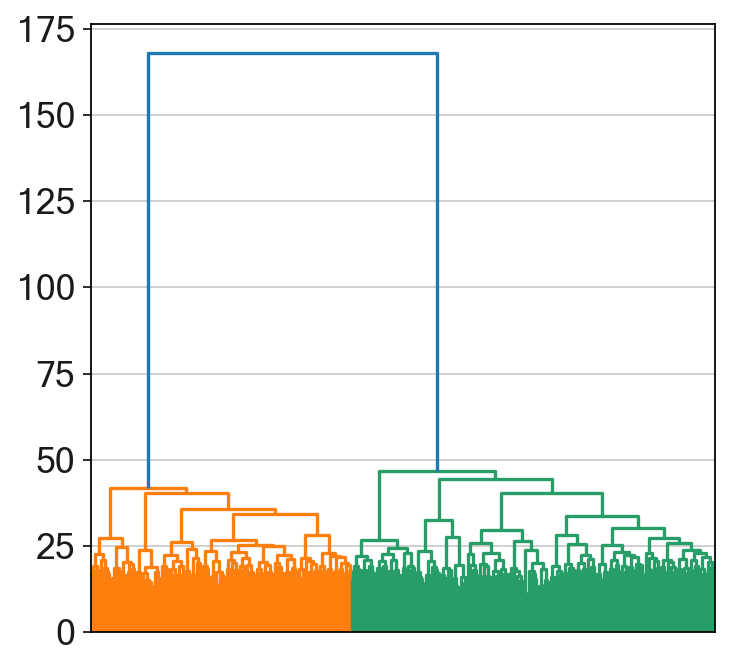

In [59]:
#calculate the clustering for each dataset
Z, dg = hierarchicalClustering(df_plot, plot = True, cth = 55)

clusters = getClusterByColor(dg, labels=df_plot.index)


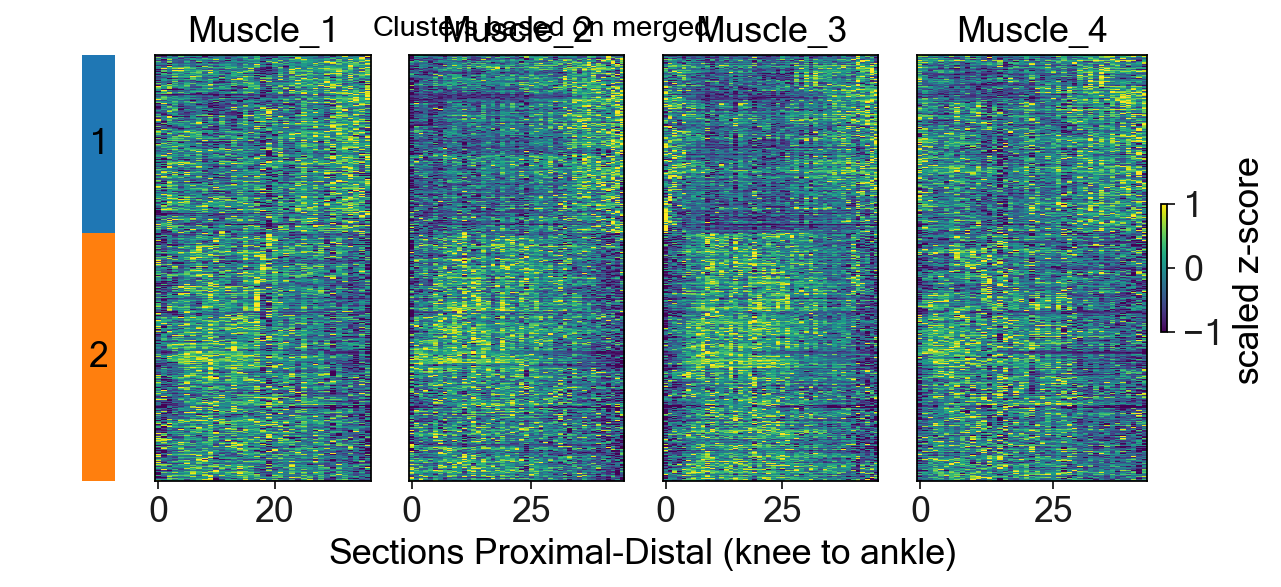

In [60]:
#Use the clustering to plot the indivudal figures
plotHeatmap(data_deg_scaled_zscores, dg, clusters, title='Clusters based on merged', figsize=(9,3.5), type_data = 'scaled z-score')
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.rcParams["font.size"] = 7
plt.savefig('DEG_heatmap.svg', format = 'svg', dpi=300, bbox_inches='tight')   
plt.show()
plt.close()


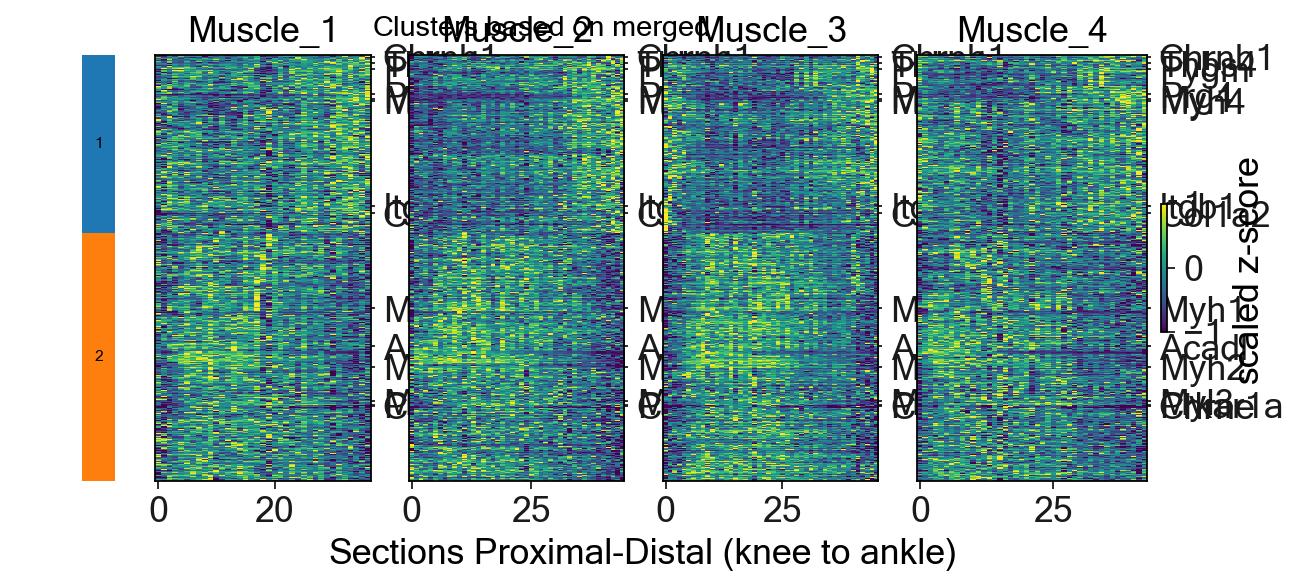

In [61]:
#Use the clustering to plot the indivudal figures
plotHeatmapAnn(data_deg_scaled_zscores, dg, clusters, title='Clusters based on merged', figsize=(9,3.5), type_data = 'scaled z-score', g_annotate=['Myh2', 'Myh1', 'Myh4', 'Myl3', 'Myl1', 'Prkar1a', 'Chrne', 'Chrnb1', 'Itgb1', 'Col1a2','Prg4', 'Thbs4', 'Acadl', 'Pygm'])
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.rcParams["font.size"] = 7
plt.savefig('DEG_heatmap_ann.svg', format = 'svg', dpi=300, bbox_inches='tight')   
plt.show()
plt.close()


In [62]:
#get the genes ids from each cluster to do GO analyses
ClusterGeneNames(data_deg_scaled_zscores['Muscle_3'], clusters, dg, file_name = '686-DEG_clusterGeneNames_hierarchical_merged.txt')


686-DEG_clusterGeneNames_hierarchical_merged.txt


Gene onthology analysis with panther (http://geneontology.org/) and website to plot dotplot results 
http://www.bioinformatics.com.cn/plot_basic_gopathway_enrichment_bubbleplot_081_en

## Genes to look at

In [63]:
path = ''
file_names = [path + 'Muscle_1_data_deg.tsv.gz', 
             path + 'Muscle_2_data_deg.tsv.gz',
              path + 'Muscle_3_data_deg.tsv.gz',
              path + 'Muscle_4_data_deg.tsv.gz']
labels = ['Muscle_1','Muscle_2','Muscle_3','Muscle_4']

#use accessData() function to obtain a dictonary with each dataset with labels as key
data_deg = accessData(file_names, labels)
data_deg['Muscle_1']

,001,002,003,004,005,006,007,008,009,010,...,028,029,030,031,032,033,034,035,036,037
new_gene,,,,,,,,,,,,,,,,,,,,,
ENSMUSG00000015568_Lpl_ProteinCoding,102.106895,95.015603,155.408216,164.753935,163.979915,172.588052,145.394149,145.074606,171.519773,202.864662,...,129.990206,141.181725,96.182194,100.423429,79.401495,112.424589,56.382597,78.742627,80.012735,71.839603
ENSMUSG00000018893_Mb_ProteinCoding,1518.684082,1361.680333,1495.883518,1555.250267,1749.442477,1692.754852,1579.371020,1825.778041,1704.596834,1840.014725,...,1329.619797,1647.371661,1299.208094,1141.418388,1271.698325,1288.290240,1164.181239,913.634448,1260.257442,1076.355662
ENSMUSG00000000031_H19_lincRNA,525.703164,648.449576,766.204651,822.846731,944.491446,1047.822927,1096.875150,967.340118,980.769105,876.118015,...,626.860417,688.002891,576.477369,569.623520,576.077236,471.466692,540.330983,361.448546,643.517559,434.813485
ENSMUSG00000021622_Ckmt2_ProteinCoding,139.201480,190.853658,184.962088,208.543574,241.144624,219.297119,197.303060,224.464510,241.261205,187.738720,...,170.845567,204.723399,153.760320,154.576528,137.108981,146.112698,129.378171,116.631008,224.699045,112.262728
ENSMUSG00000069919_Hba.a1_ProteinCoding,434.455107,204.612781,281.108230,370.550871,636.173780,915.758088,973.824615,1156.928872,679.913160,956.850945,...,388.070899,694.565328,297.923359,282.943010,269.153375,254.169061,210.163923,228.214867,429.369437,184.795065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000024548_Setbp1_ProteinCoding,2.824165,2.703446,9.605776,5.933058,3.357068,3.461574,4.689353,10.163372,7.679687,6.194287,...,7.879469,6.554118,7.232081,4.647431,10.356346,10.285955,5.219863,9.008802,4.830875,8.597566
ENSMUSG00000078941_Ak6_ProteinCoding,8.474564,8.112320,14.413950,3.389076,5.596481,13.176534,10.168966,10.163372,4.798045,7.227552,...,6.893692,9.260816,8.679558,11.622837,6.323456,11.660271,5.219863,8.006845,9.664112,11.464822
ENSMUSG00000027637_Rab5if_ProteinCoding,11.300799,21.646076,19.225655,22.088415,28.051016,26.414618,18.798797,23.761087,14.411752,15.502777,...,18.738953,16.242318,18.821816,6.971998,17.864397,28.896311,24.839897,22.056602,16.918397,20.070795


In [64]:
path = ''
file_names = [path + 'Muscle_1_data_deg_zscores.tsv.gz', 
             path + 'Muscle_2_data_deg_zscores.tsv.gz',
              path + 'Muscle_3_data_deg_zscores.tsv.gz',
              path + 'Muscle_4_data_deg_zscores.tsv.gz']
labels = ['Muscle_1','Muscle_2','Muscle_3','Muscle_4']

#use accessData() function to obtain a dictonary with each dataset with labels as key
data_deg_zscores = accessData(file_names, labels)
data_deg_zscores['Muscle_1']

,001,002,003,004,005,006,007,008,009,010,...,028,029,030,031,032,033,034,035,036,037
new_gene,,,,,,,,,,,,,,,,,,,,,
ENSMUSG00000015568_Lpl_ProteinCoding,-0.948932,-1.150101,0.563149,0.828273,0.806315,1.050516,0.279064,0.269999,1.020210,1.909419,...,-0.157923,0.159564,-1.117007,-0.996689,-1.593050,-0.656234,-2.246063,-1.611742,-1.575711,-1.807570
ENSMUSG00000018893_Mb_ProteinCoding,0.228222,-0.504750,0.121778,0.398932,1.305519,1.040872,0.511540,1.661891,1.096157,1.728355,...,-0.654425,0.829001,-0.796402,-1.533043,-0.924831,-0.847372,-1.426775,-2.596453,-0.978243,-1.836789
ENSMUSG00000000031_H19_lincRNA,-1.036785,-0.373270,0.263263,0.569445,1.227004,1.785570,2.050725,1.350514,1.423106,0.857407,...,-0.489972,-0.159462,-0.762321,-0.799370,-0.764484,-1.329964,-0.957713,-1.924674,-0.399931,-1.528095
ENSMUSG00000021622_Ckmt2_ProteinCoding,-1.345129,0.146068,-0.024021,0.656775,1.597967,0.967230,0.332262,1.116413,1.601333,0.056140,...,-0.431565,0.546487,-0.924816,-0.901252,-1.405540,-1.145603,-1.628728,-1.996738,1.123184,-2.122850
ENSMUSG00000069919_Hba.a1_ProteinCoding,-0.541062,-1.453766,-1.150003,-0.794826,0.259964,1.370194,1.600776,2.327884,0.433653,1.533374,...,-0.725254,0.491837,-1.083230,-1.142717,-1.197475,-1.256978,-1.431723,-1.360042,-0.561257,-1.532463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000024548_Setbp1_ProteinCoding,-1.243572,-1.284722,1.068093,-0.183836,-1.061920,-1.026297,-0.607781,1.258162,0.411542,-0.094790,...,0.479642,0.027866,0.258965,-0.622071,1.323942,1.299947,-0.426945,0.864601,-0.559540,0.724422
ENSMUSG00000078941_Ak6_ProteinCoding,0.275729,0.139859,2.503464,-1.631727,-0.803777,2.039336,0.911263,0.909164,-1.103253,-0.191998,...,-0.317222,0.570635,0.352618,1.456578,-0.531105,1.470619,-0.945039,0.100298,0.721903,1.397310
ENSMUSG00000027637_Rab5if_ProteinCoding,-1.726595,0.437611,-0.068735,0.530147,1.777509,1.435178,-0.158033,0.880066,-1.075792,-0.847552,...,-0.170552,-0.692842,-0.153217,-2.632170,-0.353507,1.954342,1.105751,0.523492,-0.551408,0.108066


In [65]:
path = ''
file_names = [path + 'Muscle_1_data_deg_scaled_zscores.tsv.gz', 
             path + 'Muscle_2_data_deg_scaled_zscores.tsv.gz',
              path + 'Muscle_3_data_deg_scaled_zscores.tsv.gz',
              path + 'Muscle_4_data_deg_scaled_zscores.tsv.gz']
labels = ['Muscle_1','Muscle_2','Muscle_3','Muscle_4']

#use accessData() function to obtain a dictonary with each dataset with labels as key
data_deg_scaled_zscores = accessData(file_names, labels)
data_deg_scaled_zscores['Muscle_1']

,001,002,003,004,005,006,007,008,009,010,...,028,029,030,031,032,033,034,035,036,037
new_gene,,,,,,,,,,,,,,,,,,,,,
ENSMUSG00000015568_Lpl_ProteinCoding,-0.375701,-0.472522,0.352051,0.479653,0.469085,0.586617,0.215324,0.210961,0.572031,1.000000,...,0.005005,0.157809,-0.456594,-0.398686,-0.685710,-0.234828,-1.000000,-0.694706,-0.677365,-0.788957
ENSMUSG00000018893_Mb_ProteinCoding,0.306266,-0.032696,0.257041,0.385210,0.804460,0.682075,0.437286,0.969264,0.707641,1.000000,...,-0.101912,0.584095,-0.167569,-0.508228,-0.226961,-0.191140,-0.459084,-1.000000,-0.251662,-0.648695
ENSMUSG00000000031_H19_lincRNA,-0.553308,-0.219498,0.100738,0.254777,0.585591,0.866602,1.000000,0.647728,0.684248,0.399649,...,-0.278210,-0.111932,-0.415227,-0.433866,-0.416315,-0.700805,-0.513527,-1.000000,-0.232911,-0.800483
ENSMUSG00000021622_Ckmt2_ProteinCoding,-0.582340,0.218478,0.127135,0.492744,0.998193,0.659468,0.318470,0.739583,1.000000,0.170184,...,-0.091728,0.433516,-0.356619,-0.343964,-0.614782,-0.475188,-0.734641,-0.932274,0.743219,-1.000000
ENSMUSG00000069919_Hba.a1_ProteinCoding,-0.486367,-0.959228,-0.801852,-0.617839,-0.071365,0.503832,0.623294,1.000000,0.018621,0.588374,...,-0.581795,0.048766,-0.767258,-0.798077,-0.826447,-0.857275,-0.947808,-0.910671,-0.496830,-1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000024548_Setbp1_ProteinCoding,-0.613204,-0.629738,0.315601,-0.187412,-0.540218,-0.525905,-0.357749,0.391969,0.051805,-0.151635,...,0.079167,-0.102352,-0.009499,-0.363491,0.418398,0.408757,-0.285091,0.233839,-0.338367,0.177517
ENSMUSG00000078941_Ak6_ProteinCoding,-0.077452,-0.143166,1.000000,-1.000000,-0.599559,0.775523,0.229926,0.228911,-0.744402,-0.303670,...,-0.364235,0.065180,-0.040264,0.493670,-0.467680,0.500461,-0.667881,-0.162300,0.138341,0.465005
ENSMUSG00000027637_Rab5if_ProteinCoding,-0.605114,0.338612,0.117814,0.378964,0.922890,0.773613,0.078875,0.531550,-0.321324,-0.221797,...,0.073416,-0.154334,0.080975,-1.000000,-0.006363,1.000000,0.629962,0.376062,-0.092660,0.194911


### Pie charts metabolic pathways GO

In [66]:
#access de data
#Create a variable list with the file names and one with the labels to use as dictionary keys
#path = '/Volumes/Clara/Data/re-map_MOUSE-E102/'
path=''
file_names = [path + 'Muscle_1_genes.t.t.counts_filtered_noRibo_TOMOseq2-4_normal.tsv.gz', 
             path + 'Muscle_2_genes.t.t.counts_filtered_noRibo_TOMOseq2-4_normal.tsv.gz',
             path + 'Muscle_3_genes.t.t.counts_filtered_noRibo_TOMOseq2-4_normal.tsv.gz',
             path + 'Muscle_4_genes.t.t.counts_filtered_noRibo_TOMOseq2-4_normal.tsv.gz']
labels = ['Muscle_1', 'Muscle_2', 'Muscle_3', 'Muscle_4']


#use accessData() function to obtain a dictonary with each dataset with labels as key
data_genes_filtered_normal= accessData(file_names, labels)
data_genes_filtered_normal

{'Muscle_1':                                                   001         002         003  \
 new_gene                                                                        
 ENSMUSG00000000031_H19_lincRNA             525.703164  648.449576  766.204651   
 ENSMUSG00000000056_Narf_ProteinCoding        8.474564    2.703446    0.000000   
 ENSMUSG00000000078_Klf6_ProteinCoding        5.649019    2.703446    4.801128   
 ENSMUSG00000000085_Scmh1_ProteinCoding       2.824165    0.000000    1.599985   
 ENSMUSG00000000088_Cox5a_ProteinCoding     164.952214  166.130244  184.962088   
 ...                                               ...         ...         ...   
 ENSMUSG00000115987_Vps28_ProteinCoding      16.955342   21.646076    9.605776   
 ENSMUSG00000116564_Riok2_ProteinCoding       5.649019    5.407553    1.599985   
 ENSMUSG00000116590_AC154200.1_lincRNA      104.956104   75.947139   56.233243   
 ENSMUSG00000117924_Tmem223_ProteinCoding     5.649019    0.000000   16.017459   
 ENS

In [67]:
for key in data_genes_filtered_normal:
    for index in data_genes_filtered_normal[key].index:
        if 'Acad11' in index:
            print(index)

ENSMUSG00000090150_Acad11_ProteinCoding
ENSMUSG00000090150_Acad11_ProteinCoding
ENSMUSG00000090150_Acad11_ProteinCoding


In [68]:
for key in data_genes_filtered_normal:
    for index in data_deg_scaled_zscores[key].index:
        if 'Acss1' in index:
            print(index)

In [69]:
data_charts = pd.read_csv('GO_piecharts2.txt', sep='\t')
data_charts

,gene,status,type
0,Foxk1,Not detected,1 Canonical glycolysis
1,Tpi1,AProximal-distal UP,1 Canonical glycolysis
2,Hk1,Not detected,1 Canonical glycolysis
3,Aldoa,AProximal-distal UP,1 Canonical glycolysis
4,Pfkm,Not regionalized,1 Canonical glycolysis
...,...,...,...
216,Pck2,Not detected,91 Short-chain fatty acid metabolic process
217,Oxsm,Not detected,91 Short-chain fatty acid metabolic process
218,Pck1,Not detected,91 Short-chain fatty acid metabolic process
219,Mmut,Central UP,91 Short-chain fatty acid metabolic process


In [70]:
data_count=pd.crosstab(data_charts['type'], data_charts['status'])
data_per=data_count.div(data_count.sum(axis=1), axis=0)*100
data_per.to_excel('GO_barchart.xlsx')
data_per

status,AProximal-distal UP,Central UP,Not detected,Not regionalized
type,,,,
1 Canonical glycolysis,35.294118,5.882353,35.294118,23.529412
2 Gycogen catabolic process,23.529412,0.000000,35.294118,41.176471
3 Tricarboxylic acid cycle,0.000000,37.500000,18.750000,43.750000
"4 MET, NADH to ubiquinone",0.000000,40.000000,24.000000,36.000000
"5 MET, succinate to ubiquinone",0.000000,60.000000,0.000000,40.000000
"6 MET, ubiquinol to cytochrome c",0.000000,53.846154,15.384615,30.769231
"7 MET, cytochrome c to oxygen",0.000000,55.000000,20.000000,25.000000
71 Proton motive force-driven mitochondrial ATP synthesis,0.000000,53.225806,9.677419,37.096774
"8 Carnitine metabolic process, CoA-linked",0.000000,100.000000,0.000000,0.000000


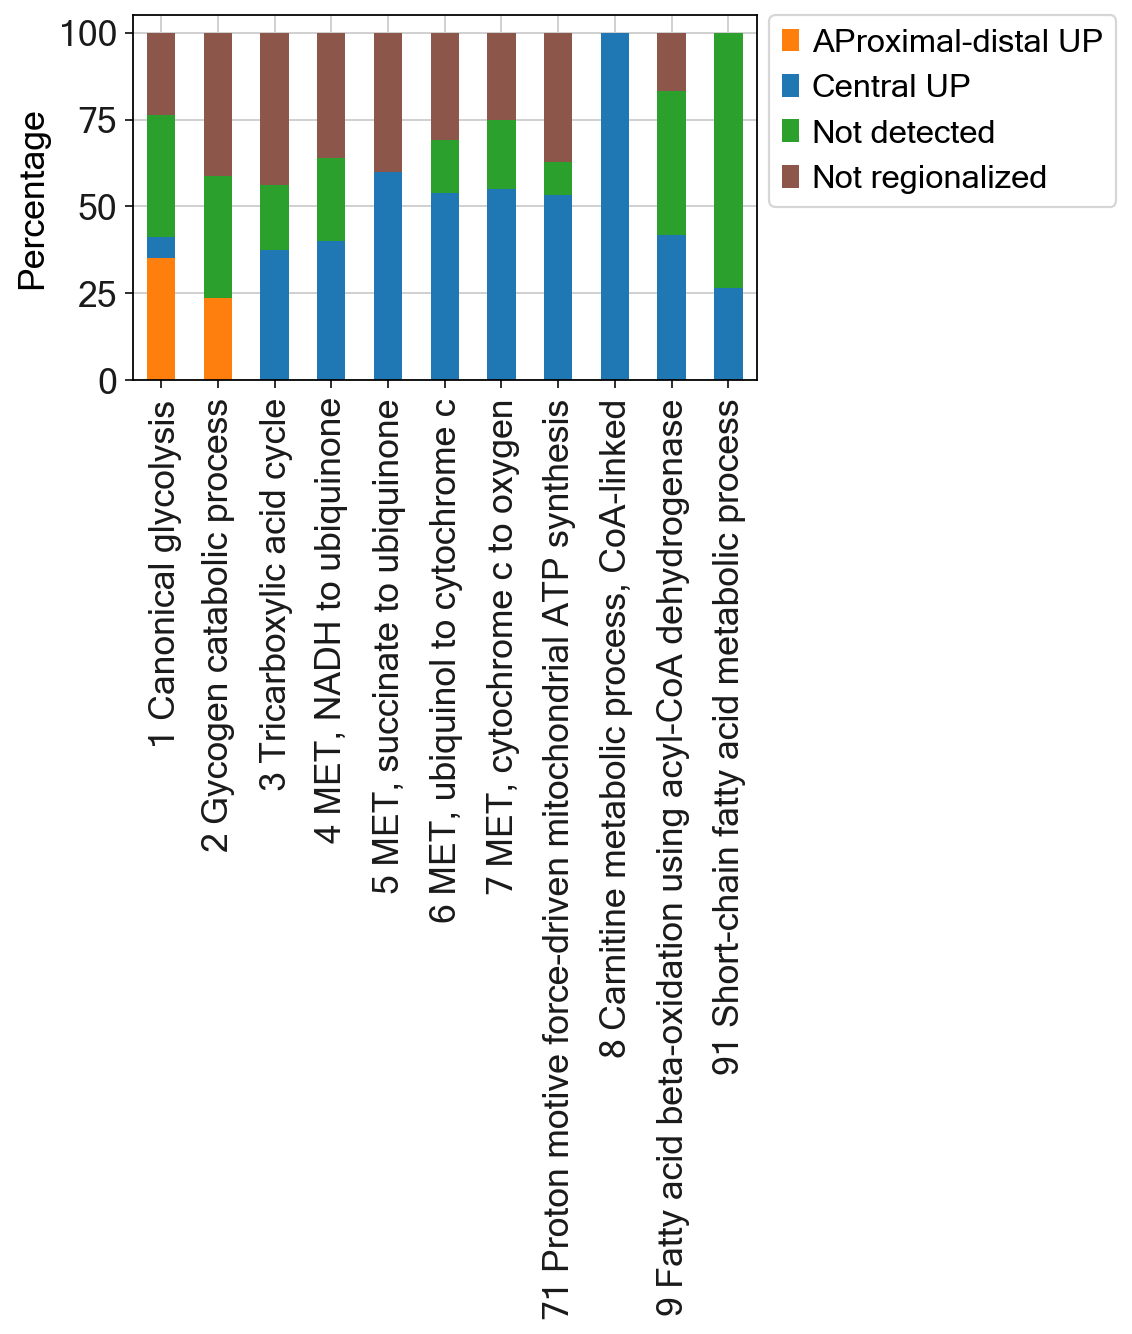

In [71]:

mycolors=['#ff7f0e','#1f77b4','#2ca02c','#8c564b']
ax=data_per.plot(kind='bar', stacked=True, color=mycolors, figsize=(5,3))

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.ylabel('Percentage')
plt.xlabel('')
ax.set_axisbelow(True)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.rcParams["font.size"] = 7
plt.savefig('GO_percentage_bar.svg', format = 'svg', dpi=300, bbox_inches='tight')  
plt.show()
plt.close()



### Compare skeletal muscle to tendon

In [72]:
coverage=[]
for key in data_genes_filtered_normal:
    coverage.append(data_genes_filtered_normal[key].sum()[0])
mean_cov=np.mean(coverage)
mean_cov
coverage

[190167.96095399137, 161939.20400793833, 191586.9682475964, 147790.26354707332]

In [73]:
data_genes_filtered_renormal = normalizeTO(data_genes_filtered_normal, factor=mean_cov)
data_genes_filtered_renormal

{'Muscle_1':                                                   001         002         003  \
 new_gene                                                                        
 ENSMUSG00000000031_H19_lincRNA             477.887460  589.469385  696.513963   
 ENSMUSG00000000056_Narf_ProteinCoding        7.703754    2.457552    0.000000   
 ENSMUSG00000000078_Klf6_ProteinCoding        5.135209    2.457552    4.364438   
 ENSMUSG00000000085_Scmh1_ProteinCoding       2.567291    0.000000    1.454457   
 ENSMUSG00000000088_Cox5a_ProteinCoding     149.948869  151.019750  168.138731   
 ...                                               ...         ...         ...   
 ENSMUSG00000115987_Vps28_ProteinCoding      15.413157   19.677242    8.732076   
 ENSMUSG00000116564_Riok2_ProteinCoding       5.135209    4.915705    1.454457   
 ENSMUSG00000116590_AC154200.1_lincRNA       95.409747   69.039313   51.118509   
 ENSMUSG00000117924_Tmem223_ProteinCoding     5.135209    0.000000   14.560580   
 ENS

In [74]:
adata_1=adata[adata.obs["Sample"] == "Muscle_1"]
data_1=pd.DataFrame(adata_1.obs)
data_1['Ckm counts'] = list(data_genes_filtered_normal['Muscle_1'].loc['ENSMUSG00000030399_Ckm_ProteinCoding'])
data_1['Ttn counts'] = list(data_genes_filtered_normal['Muscle_1'].loc['ENSMUSG00000051747_Ttn_ProteinCoding'])
data_1['Prg4 counts'] = list(data_genes_filtered_normal['Muscle_1'].loc['ENSMUSG00000006014_Prg4_ProteinCoding'])



In [75]:
adata_2=adata[adata.obs["Sample"] == "Muscle_2"]
data_2=pd.DataFrame(adata_2.obs)
data_2['Ckm counts'] = list(data_genes_filtered_normal['Muscle_2'].loc['ENSMUSG00000030399_Ckm_ProteinCoding'])
data_2['Ttn counts'] = list(data_genes_filtered_normal['Muscle_2'].loc['ENSMUSG00000051747_Ttn_ProteinCoding'])
data_2['Prg4 counts'] = list(data_genes_filtered_normal['Muscle_2'].loc['ENSMUSG00000006014_Prg4_ProteinCoding'])



In [76]:
adata_3=adata[adata.obs["Sample"] == "Muscle_3"]
data_3=pd.DataFrame(adata_3.obs)
data_3['Ckm counts'] = list(data_genes_filtered_normal['Muscle_3'].loc['ENSMUSG00000030399_Ckm_ProteinCoding'])
data_3['Ttn counts'] = list(data_genes_filtered_normal['Muscle_3'].loc['ENSMUSG00000051747_Ttn_ProteinCoding'])
data_3['Prg4 counts'] = list(data_genes_filtered_normal['Muscle_3'].loc['ENSMUSG00000006014_Prg4_ProteinCoding'])



In [77]:
adata_4=adata[adata.obs["Sample"] == "Muscle_4"]
data_4=pd.DataFrame(adata_4.obs)
data_4['Ckm counts'] = list(data_genes_filtered_normal['Muscle_4'].loc['ENSMUSG00000030399_Ckm_ProteinCoding'])
data_4['Ttn counts'] = list(data_genes_filtered_normal['Muscle_4'].loc['ENSMUSG00000051747_Ttn_ProteinCoding'])
data_4['Prg4 counts'] = list(data_genes_filtered_normal['Muscle_4'].loc['ENSMUSG00000006014_Prg4_ProteinCoding'])



In [78]:
df_1=pd.concat([data_1,data_2])
df_2=pd.concat([data_3,data_4])
data_m=pd.concat([df_1,df_2])
data_m.to_excel("source table F1 F.xlsx") 
data_m

,Section,Sample,Region,leiden,Transcript counts,PC1,PC2,color,Ckm counts,Ttn counts,Prg4 counts
0,001,Muscle_1,Proximal,Central,161211.575240,19.433060,19.433060,tab:blue,4624.992054,2113.317033,14.127725
1,002,Muscle_1,Proximal,Central,188609.317165,35.949142,35.949142,tab:blue,4680.148949,1398.423612,5.407553
2,003,Muscle_1,Proximal,Proximal-distal,285859.890922,-1.548404,-1.548404,tab:orange,5012.872300,2563.192874,3.200361
3,004,Muscle_1,Proximal,Proximal-distal,603433.080500,10.428934,10.428934,tab:orange,4560.327225,1502.613158,2.541496
4,005,Muscle_1,Transition,Central,462816.711656,7.703436,7.703436,tab:blue,5896.407883,1486.732569,5.596481
...,...,...,...,...,...,...,...,...,...,...,...
166,039,Muscle_4,Distal,Proximal-distal,348027.897739,12.789564,12.789564,tab:orange,4003.381448,981.326176,18.053081
167,040,Muscle_4,Distal,Proximal-distal,582268.965080,6.970232,6.970232,tab:orange,3788.823396,1317.873295,6.003666
168,041,Muscle_4,Distal,Proximal-distal,201367.900503,6.545357,6.545357,tab:orange,3460.371520,1312.875019,16.146559
169,042,Muscle_4,Distal,Proximal-distal,160966.128144,17.398216,17.398216,tab:orange,3320.769474,1237.182375,11.089474


In [79]:
data_m=pd.read_excel('source table F1 F.xlsx', index_col=0)  
data_m

,Section,Sample,Region,leiden,Transcript counts,PC1,PC2,color,Ckm counts,Ttn counts,Prg4 counts
0,1,Muscle_1,Proximal,Central,161211.575240,19.433060,19.433060,tab:blue,4624.992054,2113.317033,14.127725
1,2,Muscle_1,Proximal,Central,188609.317165,35.949142,35.949142,tab:blue,4680.148949,1398.423612,5.407553
2,3,Muscle_1,Proximal,Proximal-distal,285859.890922,-1.548404,-1.548404,tab:orange,5012.872300,2563.192874,3.200361
3,4,Muscle_1,Proximal,Proximal-distal,603433.080500,10.428934,10.428934,tab:orange,4560.327225,1502.613158,2.541496
4,5,Muscle_1,Transition,Central,462816.711656,7.703436,7.703436,tab:blue,5896.407883,1486.732569,5.596481
...,...,...,...,...,...,...,...,...,...,...,...
166,39,Muscle_4,Distal,Proximal-distal,348027.897739,12.789564,12.789564,tab:orange,4003.381448,981.326176,18.053081
167,40,Muscle_4,Distal,Proximal-distal,582268.965080,6.970232,6.970232,tab:orange,3788.823396,1317.873295,6.003666
168,41,Muscle_4,Distal,Proximal-distal,201367.900503,6.545357,6.545357,tab:orange,3460.371520,1312.875019,16.146559
169,42,Muscle_4,Distal,Proximal-distal,160966.128144,17.398216,17.398216,tab:orange,3320.769474,1237.182375,11.089474


In [80]:
data_m_ttn=data_m[['Sample','leiden','Ttn counts']]
data_m_ttn=data_m_ttn.groupby(['Sample','leiden']).agg(['mean', 'count', 'std'])
ci95_hi = []
ci95_lo = []

for i in data_m_ttn.index:
    m, c, s = data_m_ttn.loc[i]
    ci95_hi.append(m + 1.96*s/math.sqrt(c))
    ci95_lo.append(m - 1.96*s/math.sqrt(c))

data_m_ttn['Ttn counts','ci95_hi'] = ci95_hi
data_m_ttn['Ttn counts','ci95_lo'] = ci95_lo
data_m_ttn.to_excel("source table F1 F ttn.xlsx") 

data_m_ckm=data_m[['Sample','leiden','Ckm counts']]
data_m_ckm=data_m_ckm.groupby(['Sample','leiden']).agg(['mean', 'count', 'std'])
ci95_hi = []
ci95_lo = []

for i in data_m_ckm.index:
    m, c, s = data_m_ckm.loc[i]
    ci95_hi.append(m + 1.96*s/math.sqrt(c))
    ci95_lo.append(m - 1.96*s/math.sqrt(c))

data_m_ckm['Ckm counts','ci95_hi'] = ci95_hi
data_m_ckm['Ckm counts','ci95_lo'] = ci95_lo
data_m_ckm.to_excel("source table F1 F ckm.xlsx") 

data_m_prg4=data_m[['Sample','leiden','Prg4 counts']]
data_m_prg4=data_m_prg4.groupby(['Sample','leiden']).agg(['mean', 'count', 'std'])
ci95_hi = []
ci95_lo = []

for i in data_m_prg4.index:
    m, c, s = data_m_prg4.loc[i]
    ci95_hi.append(m + 1.96*s/math.sqrt(c))
    ci95_lo.append(m - 1.96*s/math.sqrt(c))

data_m_prg4['Prg4 counts','ci95_hi'] = ci95_hi
data_m_prg4['Prg4 counts','ci95_lo'] = ci95_lo
data_m_prg4.to_excel("source table F1 F prg4.xlsx") 
data_m_prg4

Prg4 counts                                       
                                mean count        std    ci95_hi    ci95_lo
Sample   leiden                                                            
Muscle_1 Central           10.294319    23   6.537775  12.966230   7.622407
         Proximal-distal   41.562631    14  27.167244  55.793703  27.331558
Muscle_2 Central            6.699675    30   5.091562   8.521667   4.877683
         Proximal-distal   19.905331    15   9.598410  24.762797  15.047866
Muscle_3 Central            4.763931    25   3.287299   6.052553   3.475310
         Proximal-distal    9.840286    21   5.941865  12.381664   7.298908
Muscle_4 Central            3.464369    26   2.254902   4.331125   2.597612
         Proximal-distal    8.381624    17   5.539154  11.014771   5.748477

In [81]:
pvals=[]
pvals.append(ttest_ind(data_1.loc[data_1['leiden']=='Central']['Ckm counts'] , data_1.loc[data_1['leiden']=='Proximal-distal']['Ckm counts'])[1])
pvals.append(ttest_ind(data_2.loc[data_2['leiden']=='Central']['Ckm counts'] , data_2.loc[data_2['leiden']=='Proximal-distal']['Ckm counts'])[1])
pvals.append(ttest_ind(data_3.loc[data_3['leiden']=='Central']['Ckm counts'] , data_3.loc[data_3['leiden']=='Proximal-distal']['Ckm counts'])[1])
pvals.append(ttest_ind(data_4.loc[data_4['leiden']=='Central']['Ckm counts'] , data_4.loc[data_4['leiden']=='Proximal-distal']['Ckm counts'])[1])
print(pvals)
multipletests(pvals, alpha=0.05, method='fdr_bh')

[0.3817388842210654, 0.033808372319248825, 0.08614298562415146, 0.24275691609831807]


(array([False, False, False, False]),
 array([0.38173888, 0.13523349, 0.17228597, 0.32367589]),
 0.012741455098566168,
 0.0125)

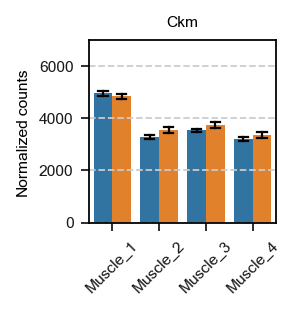

In [82]:
plt.figure(figsize=(1.5, 1.5))
sns.barplot(data=data_m, x="Sample", y="Ckm counts", hue="leiden", errorbar='se', errwidth=1, errcolor = 'black', capsize=0.2)
# Major ticks every 2000
major_ticks = np.arange(0, 6001, 2000)
plt.yticks(major_ticks)
plt.grid(which='major', axis='y', linestyle='--')
plt.xticks(rotation=45, fontsize=7, fontname="Microsoft Sans Serif")
plt.yticks(fontsize=7, fontname="Microsoft Sans Serif")
plt.ylabel('Normalized counts', fontsize=7, fontname="Microsoft Sans Serif")
plt.title('Ckm', fontsize=7, fontname="Microsoft Sans Serif", style='italic')
plt.xlabel('')
plt.ylim(0, 7000)
plt.legend([],[], frameon=False)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.rcParams["font.size"] = 7
plt.savefig('barplot-ckm-muscles.svg', format = 'svg', dpi=300, bbox_inches='tight')  
plt.show()
plt.close()

In [83]:
pvals=[]
pvals.append(ttest_ind(data_1.loc[data_1['leiden']=='Central']['Ttn counts'] , data_1.loc[data_1['leiden']=='Proximal-distal']['Ttn counts'])[1])
pvals.append(ttest_ind(data_2.loc[data_2['leiden']=='Central']['Ttn counts'] , data_2.loc[data_2['leiden']=='Proximal-distal']['Ttn counts'])[1])
pvals.append(ttest_ind(data_3.loc[data_3['leiden']=='Central']['Ttn counts'] , data_3.loc[data_3['leiden']=='Proximal-distal']['Ttn counts'])[1])
pvals.append(ttest_ind(data_4.loc[data_4['leiden']=='Central']['Ttn counts'] , data_4.loc[data_4['leiden']=='Proximal-distal']['Ttn counts'])[1])
print(pvals)
multipletests(pvals, alpha=0.05, method='fdr_bh')

[0.48906627789646395, 0.031418224209735356, 0.1382526325572813, 0.48967940605759663]


(array([False, False, False, False]),
 array([0.48967941, 0.1256729 , 0.27650527, 0.48967941]),
 0.012741455098566168,
 0.0125)

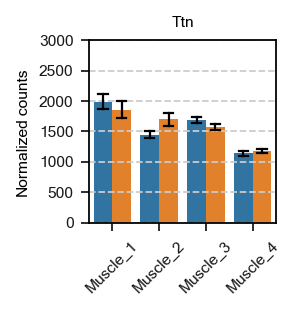

In [84]:
plt.figure(figsize=(1.5, 1.5))
sns.barplot(data=data_m, x="Sample", y="Ttn counts", hue="leiden", errorbar='se', errwidth=1, errcolor = 'black', capsize=0.2)
# Major ticks every 2000
major_ticks = np.arange(0, 3001, 500)
plt.yticks(major_ticks)
plt.grid(which='major', axis='y', linestyle='--')
plt.xticks(rotation=45, fontsize=7, fontname="Microsoft Sans Serif")
plt.yticks(fontsize=7, fontname="Microsoft Sans Serif")
plt.ylabel('Normalized counts', fontsize=7, fontname="Microsoft Sans Serif")
plt.title('Ttn', fontsize=7, fontname="Microsoft Sans Serif", style='italic')
plt.xlabel('')
plt.ylim(0, 3000)
plt.legend([],[], frameon=False)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.rcParams["font.size"] = 7
plt.savefig('barplot-ttn-muscles.svg', format = 'svg', dpi=300, bbox_inches='tight')  
plt.show()
plt.close()

In [85]:
pvals=[]
pvals.append(ttest_ind(data_1.loc[data_1['leiden']=='Central']['Prg4 counts'] , data_1.loc[data_1['leiden']=='Proximal-distal']['Prg4 counts'])[1])
pvals.append(ttest_ind(data_2.loc[data_2['leiden']=='Central']['Prg4 counts'] , data_2.loc[data_2['leiden']=='Proximal-distal']['Prg4 counts'])[1])
pvals.append(ttest_ind(data_3.loc[data_3['leiden']=='Central']['Prg4 counts'] , data_3.loc[data_3['leiden']=='Proximal-distal']['Prg4 counts'])[1])
pvals.append(ttest_ind(data_4.loc[data_4['leiden']=='Central']['Prg4 counts'] , data_4.loc[data_4['leiden']=='Proximal-distal']['Prg4 counts'])[1])
print(pvals)
multipletests(pvals, alpha=0.05, method='fdr_bh')

[6.1476354781086425e-06, 2.985825184643325e-07, 0.0006698510121122916, 0.0002150134345348445]


(array([ True,  True,  True,  True]),
 array([1.22952710e-05, 1.19433007e-06, 6.69851012e-04, 2.86684579e-04]),
 0.012741455098566168,
 0.0125)

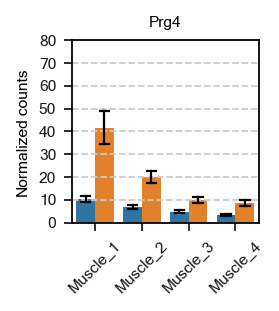

In [86]:
plt.figure(figsize=(1.5, 1.5))
sns.barplot(data=data_m, x="Sample", y="Prg4 counts", hue="leiden", errorbar='se', errwidth=1, errcolor = 'black', capsize=0.2)
# Major ticks every 2000
major_ticks = np.arange(0, 81, 10)
plt.yticks(major_ticks)
plt.grid(which='major', axis='y', linestyle='--')
plt.xticks(rotation=45, fontsize=7, fontname="Microsoft Sans Serif")
plt.yticks(fontsize=7, fontname="Microsoft Sans Serif")
plt.ylabel('Normalized counts', fontsize=7, fontname="Microsoft Sans Serif")
plt.title('Prg4', fontsize=7, fontname="Microsoft Sans Serif", style='italic')
plt.xlabel('')
plt.ylim(0, 80)
plt.legend([],[], frameon=False)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.rcParams["font.size"] = 7
plt.savefig('barplot-prg4-muscles.svg', format = 'svg', dpi=300, bbox_inches='tight')  
plt.show()
plt.close()

### Metabolism genes

In [87]:
#select the specific genes
gly_genes=['ENSMUSG00000030695_Aldoa_ProteinCoding', 'ENSMUSG00000000628_Hk2_ProteinCoding', 'ENSMUSG00000060600_Eno3_ProteinCoding'
          'ENSMUSG00000023456_Tpi1_ProteinCoding', 'ENSMUSG00000057666_Gapdh_ProteinCoding', 'ENSMUSG00000062070_Pgk1_ProteinCoding',
          'ENSMUSG00000032294_Pkm_ProteinCoding', 'ENSMUSG00000063229_Ldha_ProteinCoding', 'ENSMUSG00000032648_Pygm_ProteinCoding', 'ENSMUSG00000025791_Pgm1_ProteinCoding','ENSMUSG00000033400_Agl_ProteinCoding' ]
tca_genes=['ENSMUSG00000002010_Idh3g_ProteinCoding', 'ENSMUSG00000030541_Idh2_ProteinCoding', 'ENSMUSG00000032279_Idh3a_ProteinCoding',
          'ENSMUSG00000020456_Ogdh_ProteinCoding', 'ENSMUSG00000021748_Pdhb_ProteinCoding', 'ENSMUSG00000022110_Sucla2_ProteinCoding',
          'ENSMUSG00000021577_Sdha_ProteinCoding', 'ENSMUSG00000009863_Sdhb_ProteinCoding', 'ENSMUSG00000058076_Sdhc_ProteinCoding',
          'ENSMUSG00000020321_Mdh1_ProteinCoding', 'ENSMUSG00000019179_Mdh2_ProteinCoding']
list_g=[]
for gene in gly_genes:
    list_g.append(gene.split('_')[1])

list_t=[]
for gene in tca_genes:
    list_t.append(gene.split('_')[1])

list_f=['Dlat', 'Acss2', 'Pdhx', 'Pdhb','Acadl','Crat','Acadm','Etfb', 'Acadvl', 'Etfa','Mmut']
list_a=['Got1','Got2','Dlst','Cpt1b','Cat','Cpt2','Acadm','Acadl', 'Pdk4', 'Pdk2', 'Pdk1']
list_e1=['Ndufa3', 'Ndufs3', 'Ndufb3', 'Ndufb10', 'Aifm1', 'Ndufa1', 'Ndufs8', 'Ndufs7', 'Ndufa12', 'Ndufb8', 'Ndufs1', 'Ndufs2', 'Ndufs6', 'Ndufa5', 'Ndufb9', 'Ndufab1', 'Ndufb1.ps', 'Ndufa11', 'Ndufa9', 'Ndufa8', 'Ndufb5', 'Ndufa6']
list_e2=['Sdhb', 'Sdha', 'Sdhc', 'Sdhaf4']
list_e3=['Uqcrc2', 'Uqcrq', 'Uqcrc1', 'Uqcrh', 'Cycs', 'Uqcrfs1', 'Uqcrb', 'Cyc1']
list_e4=['Cox6c', 'Cox4i1', 'Cox7c', 'Cox8a', 'Cox5b', 'Cox6a2', 'Cox7a1', 'mt.Co3', 'Cox5a', 'Cycs', 'Cox8b']
list_e5=['Atp5a1', 'Atp5h', 'Atp5e', 'Atp5k', 'Atp5b', 'Atp5j2', 'Atp5j', 'mt.Atp8', 'Atp5pb', 'Atp5d', 'Atp5c1', 'Atp5o', 'Atp5g1']


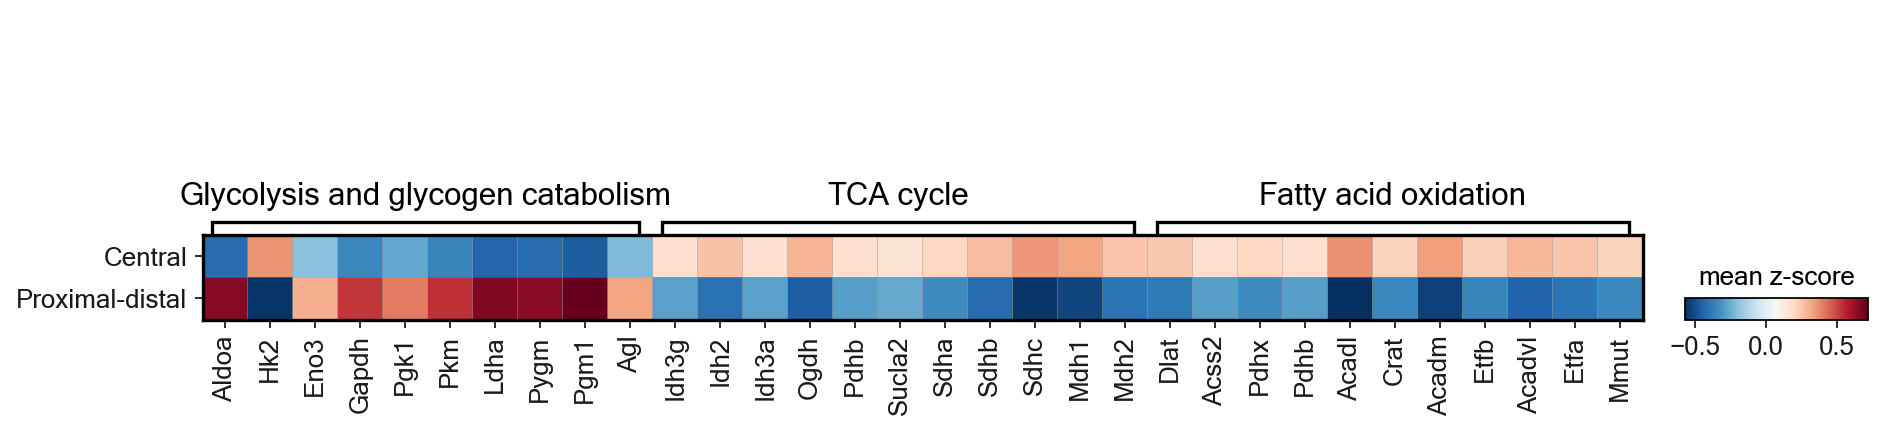

In [88]:
marker_genes_dict = {
    'Glycolysis and glycogen catabolism': list_g,
    'TCA cycle': list_t,
    'Fatty acid oxidation': list_f,
}

sc.set_figure_params(fontsize=14)
sc.pl.matrixplot(adata, marker_genes_dict, groupby='leiden',  cmap='RdBu_r', gene_symbols='gene_name', colorbar_title='mean z-score', var_group_rotation=0, show=False)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 14
plt.savefig('heatmap-pathway1.svg', format = 'svg', dpi=300, bbox_inches='tight')  
plt.show()
plt.close()



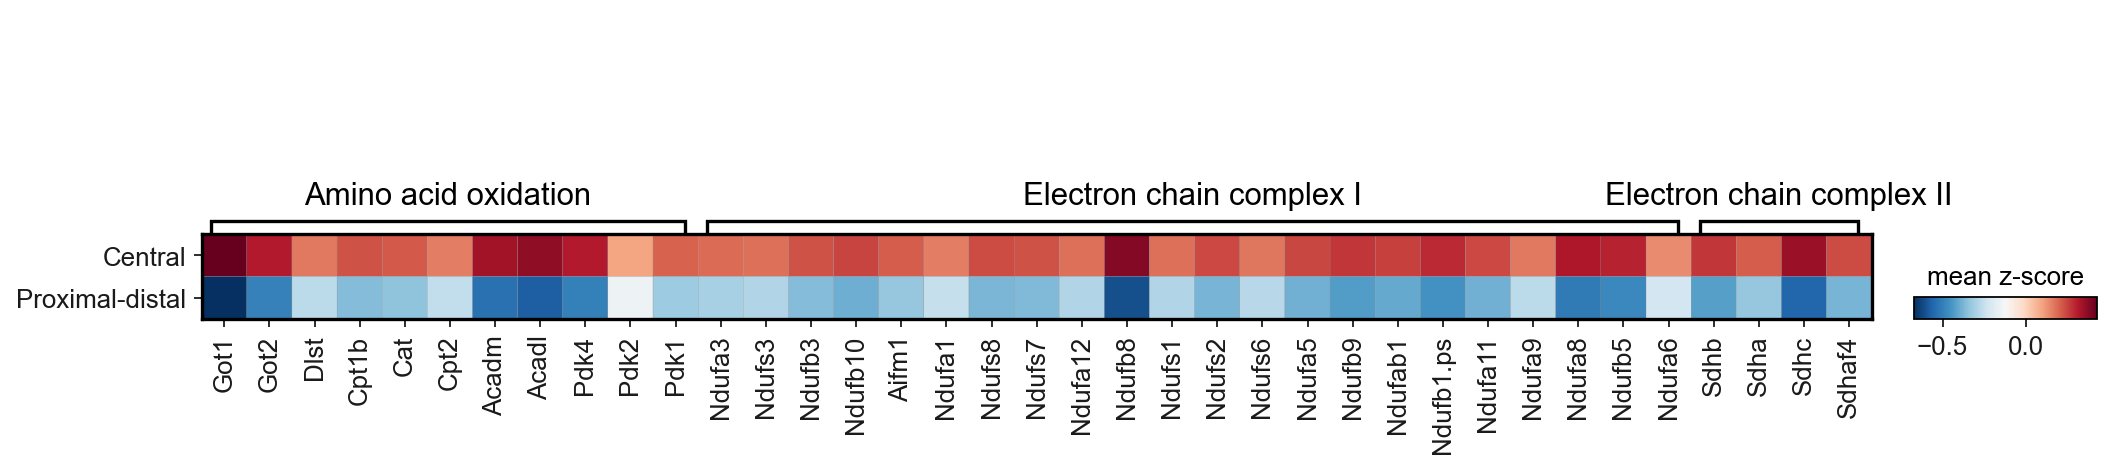

In [89]:
marker_genes_dict = {
    'Amino acid oxidation': list_a,
    'Electron chain complex I': list_e1,
    'Electron chain complex II': list_e2,
}
sc.set_figure_params(fontsize=14)
sc.pl.matrixplot(adata, marker_genes_dict, groupby='leiden',  cmap='RdBu_r', gene_symbols='gene_name', colorbar_title='mean z-score', var_group_rotation=0, show=False)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 14
plt.savefig('heatmap-pathway2.svg', format = 'svg', dpi=300, bbox_inches='tight')  
plt.show()
plt.close()

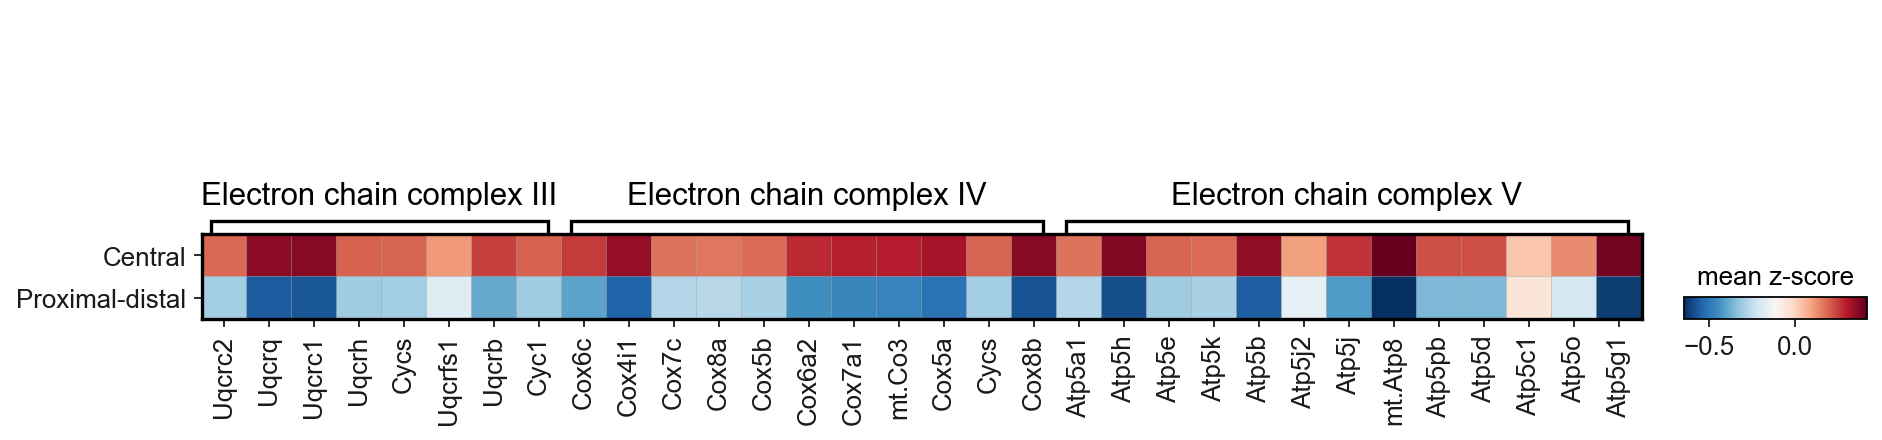

In [90]:
marker_genes_dict = {
    'Electron chain complex III': list_e3,
    'Electron chain complex IV': list_e4,
    'Electron chain complex V': list_e5
}
sc.set_figure_params(fontsize=14)
sc.pl.matrixplot(adata, marker_genes_dict, groupby='leiden',  cmap='RdBu_r', gene_symbols='gene_name', colorbar_title='mean z-score', var_group_rotation=0, show=False)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 14
plt.savefig('heatmap-pathway3.svg', format = 'svg', dpi=300, bbox_inches='tight')  
plt.show()
plt.close()

In [91]:
gene_ids = adata.var.index.values 
clusters = adata.obs['leiden'].cat.categories 
obs = adata[:,gene_ids].X.toarray() 
obs = pd.DataFrame(obs,columns=gene_ids,index=adata.obs['leiden'])
marker_genes = list_g+list_t+list_f+list_a+list_e1+list_e2+list_e3+list_e4+list_e5
out = [id for id in obs.columns if any(g in id for g in marker_genes)]
average_obs = obs.groupby(level=0).mean() 
average_obs=average_obs[out]
average_obs.T.to_excel("cluster-metabolism_average.xlsx") 
average_obs

,ENSMUSG00000000088_Cox5a_ProteinCoding,ENSMUSG00000000168_Dlat_ProteinCoding,ENSMUSG00000000399_Ndufa9_ProteinCoding,ENSMUSG00000000563_Atp5pb_ProteinCoding,ENSMUSG00000000628_Hk2_ProteinCoding,ENSMUSG00000002010_Idh3g_ProteinCoding,ENSMUSG00000002379_Ndufa11_ProteinCoding,ENSMUSG00000003072_Atp5d_ProteinCoding,ENSMUSG00000004610_Etfb_ProteinCoding,ENSMUSG00000004789_Dlst_ProteinCoding,...,ENSMUSG00000062908_Acadm_ProteinCoding,ENSMUSG00000063229_Ldha_ProteinCoding,ENSMUSG00000063694_Cycs_ProteinCoding,ENSMUSG00000063882_Uqcrh_ProteinCoding,ENSMUSG00000064356_mt.Atp8_ProteinCoding,ENSMUSG00000064358_mt.Co3_ProteinCoding,ENSMUSG00000074211_Sdhaf1_ProteinCoding,ENSMUSG00000074218_Cox7a1_ProteinCoding,ENSMUSG00000078937_Cpt1b_ProteinCoding,ENSMUSG00000113902_Ndufb1.ps_ProteinCoding
leiden,,,,,,,,,,,,,,,,,,,,,
Central,0.326383,0.246040,0.170922,0.227440,0.361253,0.179334,0.245767,0.227657,0.228169,0.171790,...,0.340868,-0.436097,0.192667,0.196739,0.416413,0.303438,-0.022854,0.299606,0.229562,0.291439
Proximal-distal,-0.506625,-0.381913,-0.265312,-0.353041,-0.560750,-0.278370,-0.381490,-0.353378,-0.354172,-0.266659,...,-0.529109,0.676927,-0.299065,-0.305386,-0.646372,-0.471008,0.035475,-0.465061,-0.356335,-0.452384


### Fiber type hetereogeneity

In [92]:
genes=[]
for index in data_deg_scaled_zscores['Muscle_1'].index:
    if 'Myh' in index or 'Myl' in index or 'Tnn' in index or 'Myo' in index or 'Myb' in index or 'Lmod' in index or 'Actn' in index:
        genes.append(index)
        print(index)
data_deg_sarc={}
for key in data_deg:
    data_deg_sarc[key]=data_deg_scaled_zscores[key].loc[genes]

ENSMUSG00000033196_Myh2_ProteinCoding
ENSMUSG00000056328_Myh1_ProteinCoding
ENSMUSG00000052374_Actn2_ProteinCoding
ENSMUSG00000018830_Myh11_ProteinCoding
ENSMUSG00000059741_Myl3_ProteinCoding
ENSMUSG00000029683_Lmod2_ProteinCoding
ENSMUSG00000022836_Mylk_ProteinCoding
ENSMUSG00000025716_Myo3a_ProteinCoding
ENSMUSG00000030672_Mylpf_ProteinCoding
ENSMUSG00000006457_Actn3_ProteinCoding
ENSMUSG00000061816_Myl1_ProteinCoding
ENSMUSG00000038670_Mybpc2_ProteinCoding
ENSMUSG00000057003_Myh4_ProteinCoding
ENSMUSG00000031097_Tnni2_ProteinCoding
ENSMUSG00000017300_Tnnc2_ProteinCoding
ENSMUSG00000061723_Tnnt3_ProteinCoding
ENSMUSG00000024049_Myom1_ProteinCoding
ENSMUSG00000044951_Mylk4_ProteinCoding
ENSMUSG00000020061_Mybpc1_ProteinCoding
ENSMUSG00000031461_Myom2_ProteinCoding
ENSMUSG00000049173_Myoz3_ProteinCoding


In [93]:
adata_plot=adata[adata.obs["leiden"] == "Central"]
ann=pd.DataFrame(adata_plot.obs)
df_c=adata[adata.obs["leiden"] == "Central"].to_df().T
df_a=adata[adata.obs["leiden"] == "Proximal-distal"].to_df().T
df_plot=pd.concat([df_c, df_a], axis=1).loc[genes]
df_plot

,0,1,4,5,6,7,8,9,10,11,...,161,162,163,164,165,166,167,168,169,170
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSMUSG00000033196_Myh2_ProteinCoding,-0.618054,-1.705087,-0.832863,-0.425516,-0.614557,0.241535,-0.070576,0.135178,0.075332,1.263828,...,-0.496471,-0.910023,-0.279173,0.178233,-0.653705,-1.119463,-0.346001,-0.335183,-1.121501,-0.656348
ENSMUSG00000056328_Myh1_ProteinCoding,0.548705,-1.806578,-0.081532,-0.338300,-0.662994,-0.493166,0.634270,0.472503,-0.988221,0.517157,...,-0.328900,0.015883,-0.786190,0.639261,-0.957980,-1.263714,-0.652799,0.654997,-0.362764,0.049967
ENSMUSG00000052374_Actn2_ProteinCoding,-2.607302,-1.939021,-0.184370,1.130215,0.027126,-0.965779,1.025054,0.208788,-0.663375,1.231139,...,-0.490857,0.197309,-0.006912,0.200721,-0.032493,-0.213213,-1.751265,-1.590583,-0.823443,-1.277669
ENSMUSG00000018830_Myh11_ProteinCoding,-1.711675,-0.949972,0.394105,4.067545,1.606453,1.560427,1.362704,0.425077,-0.767256,1.034960,...,-0.722279,-0.233068,-0.973116,-0.723951,-1.010468,-0.973317,-0.691068,-0.915611,-0.655560,-0.675942
ENSMUSG00000059741_Myl3_ProteinCoding,-1.500566,-1.535384,-0.214902,0.086346,-1.187604,0.742900,0.457391,0.218988,0.103327,-0.533840,...,1.233239,0.531353,1.480424,-0.095614,-0.288700,-0.668159,-0.592888,-1.587603,-1.587603,-1.587603
ENSMUSG00000029683_Lmod2_ProteinCoding,-0.986463,-1.440333,-0.994558,-1.003176,0.555774,0.755711,-0.229221,-0.583984,0.210059,0.046563,...,-1.060432,1.851624,0.748645,0.856056,1.782694,-1.132178,-1.306838,1.886460,0.745460,-1.758549
ENSMUSG00000022836_Mylk_ProteinCoding,0.631363,-0.027299,-0.778343,3.465047,0.235727,2.326370,1.472873,1.285523,-1.010847,-0.312022,...,-0.034497,-0.238003,-0.252414,-1.273170,-0.363861,-0.253014,-0.783086,-0.080832,-0.254830,1.564153
ENSMUSG00000025716_Myo3a_ProteinCoding,0.401230,-0.843935,-0.507806,0.270554,-0.412124,-0.280756,0.785712,-0.273336,-0.736789,-0.718854,...,-0.749559,-0.863927,0.440159,0.216593,-0.030182,-1.710866,-0.860693,0.492140,0.434006,-0.231563
ENSMUSG00000030672_Mylpf_ProteinCoding,1.783196,0.130182,0.008487,0.583348,-1.108661,-1.209743,-0.254891,-0.330720,-1.062759,0.491710,...,0.138056,1.126879,1.106511,1.451523,1.295676,1.100055,-0.180892,1.359898,1.178880,-0.300307


In [94]:
genes_names=[]
for gene in genes:
    genes_names.append(gene.split('_')[1])
genes_names.remove('Myh11')
genes_names

['Myh2',
 'Myh1',
 'Actn2',
 'Myl3',
 'Lmod2',
 'Mylk',
 'Myo3a',
 'Mylpf',
 'Actn3',
 'Myl1',
 'Mybpc2',
 'Myh4',
 'Tnni2',
 'Tnnc2',
 'Tnnt3',
 'Myom1',
 'Mylk4',
 'Mybpc1',
 'Myom2',
 'Myoz3']

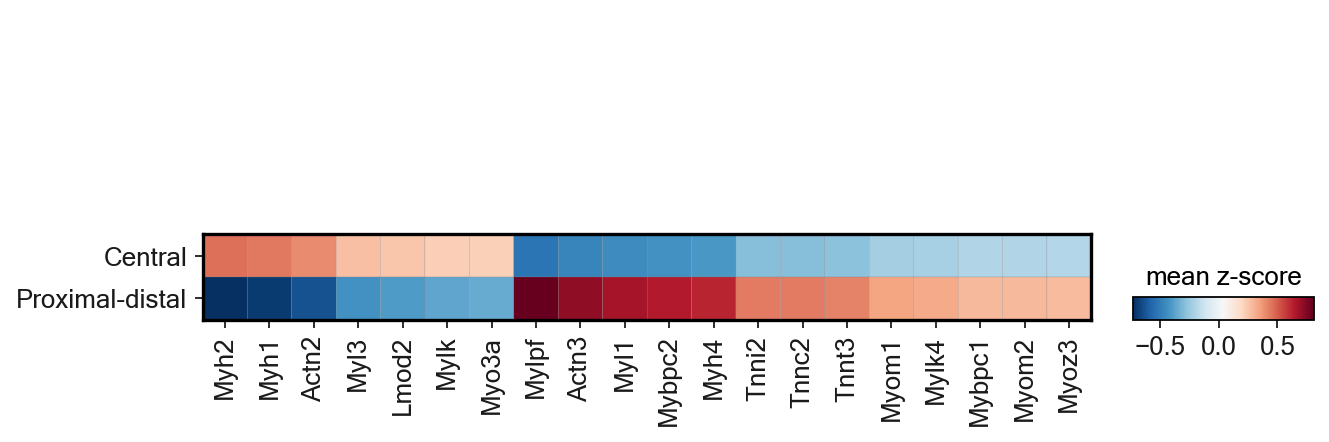

In [95]:
sc.set_figure_params(scanpy=True, fontsize=14)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.rcParams["font.size"] = 14
sc.pl.matrixplot(adata, genes_names, groupby='leiden',  cmap='RdBu_r', gene_symbols='gene_name', colorbar_title='mean z-score', 
                 show=False)
plt.savefig('heatmap-sarcomer-genes.svg', format = 'svg', dpi=300, bbox_inches='tight')  
plt.show()
plt.close()

In [96]:
gene_ids = adata.var.index.values 
clusters = adata.obs['leiden'].cat.categories 
obs = adata[:,gene_ids].X.toarray() 
obs = pd.DataFrame(obs,columns=gene_ids,index=adata.obs['leiden'])
marker_genes = genes
out = [id for id in obs.columns if any(g in id for g in marker_genes)]
average_obs = obs.groupby(level=0).mean() 
average_obs=average_obs[out]
average_obs.T.to_excel("cluster-sarcomere_average.xlsx") 
average_obs

,ENSMUSG00000006457_Actn3_ProteinCoding,ENSMUSG00000017300_Tnnc2_ProteinCoding,ENSMUSG00000018830_Myh11_ProteinCoding,ENSMUSG00000020061_Mybpc1_ProteinCoding,ENSMUSG00000022836_Mylk_ProteinCoding,ENSMUSG00000024049_Myom1_ProteinCoding,ENSMUSG00000025716_Myo3a_ProteinCoding,ENSMUSG00000029683_Lmod2_ProteinCoding,ENSMUSG00000030672_Mylpf_ProteinCoding,ENSMUSG00000031097_Tnni2_ProteinCoding,...,ENSMUSG00000033196_Myh2_ProteinCoding,ENSMUSG00000038670_Mybpc2_ProteinCoding,ENSMUSG00000044951_Mylk4_ProteinCoding,ENSMUSG00000049173_Myoz3_ProteinCoding,ENSMUSG00000052374_Actn2_ProteinCoding,ENSMUSG00000056328_Myh1_ProteinCoding,ENSMUSG00000057003_Myh4_ProteinCoding,ENSMUSG00000059741_Myl3_ProteinCoding,ENSMUSG00000061723_Tnnt3_ProteinCoding,ENSMUSG00000061816_Myl1_ProteinCoding
leiden,,,,,,,,,,,,,,,,,,,,,
Central,-0.463035,-0.283238,0.262389,-0.187552,0.231762,-0.219863,0.221875,0.253484,-0.520526,-0.282634,...,0.466473,-0.419479,-0.213823,-0.182992,0.403958,0.445048,-0.403282,0.272220,-0.271279,-0.438602
Proximal-distal,0.718741,0.439653,-0.407291,0.291125,-0.359751,0.341280,-0.344403,-0.393468,0.807980,0.438715,...,-0.724077,0.651131,0.331904,0.284048,-0.627039,-0.690821,0.625990,-0.422551,0.421090,0.680816
